# 1000 Genomes Analysis (tsinfer)

## Line plot of Location vs distance to the theoritical (kingman) mean, by population.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

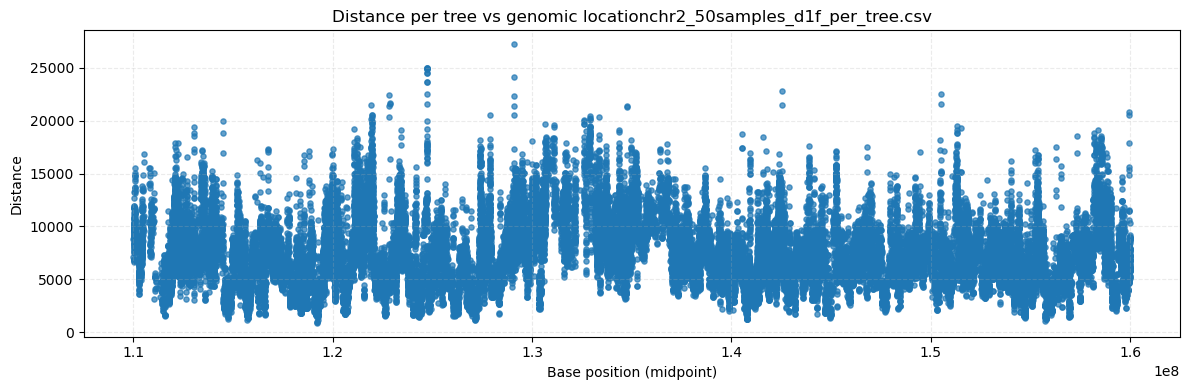

In [2]:
base = Path('.')
candidates = [ 
    base / 'chr2_50samples_dif_per_tree.csv',
    base / 'chr2_50samples_d1f_per_tree.csv',
    base / 'dif_per_tree.csv',
    base / 'd1f_per_tree.csv',
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('No distance CSV found. Expected one of: ' + ', '.join(str(p.name) for p in candidates))

df = pd.read_csv(csv_path)

if 'mid' not in df.columns:
    raise KeyError("Column 'mid' not found in distance CSV.")

dist_col = None
for c in ['distance', 'd1f_distance', 'dif_distance']:
    if c in df.columns:
        dist_col = c
        break
if dist_col is None:
    raise KeyError("No distance column found. Tried: distance, d1f_distance, dif_distance")

plt.figure(figsize=(12, 4))
plt.scatter(df['mid'], df[dist_col], s=14, alpha=0.7)
plt.xlabel('Base position (midpoint)')
plt.ylabel('Distance')
plt.title(f'Distance per tree vs genomic location{csv_path.name}')
plt.grid(alpha=0.25, linestyle='--')
plt.tight_layout()
plt.show()

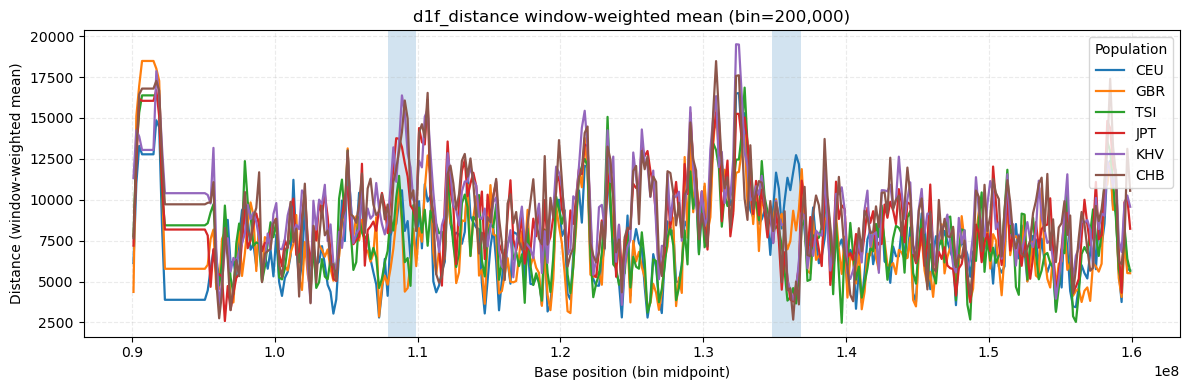

In [8]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------
# Load CSVs (per population)
# -----------------------
base = Path(".")
results_dir = base / "results"

# NOTE: 1000 Genomes population is CEU (not CER)
target_pops = ["CEU", "GBR", "TSI", "JPT", "KHV", "CHB"]

csv_paths = {pop: results_dir / f"chr2_50samples_{pop}_d1f_per_tree.csv" for pop in target_pops}

missing = [pop for pop, p in csv_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing distance CSV(s): "
        + ", ".join(f"{pop} ({csv_paths[pop].name})" for pop in missing)
    )

# Read CSVs
dfs = {pop: pd.read_csv(path) for pop, path in csv_paths.items()}

# Detect distance column (assume consistent across files)
dist_candidates = ["distance", "d1f_distance", "dif_distance"]
dist_col = next((c for c in dist_candidates if c in next(iter(dfs.values())).columns), None)
if dist_col is None:
    raise KeyError("No distance column found. Tried: " + ", ".join(dist_candidates))

# Validate + coerce types
required_cols = ["left", "right", dist_col]
for pop, df in dfs.items():
    missing_cols = [c for c in required_cols if c not in df.columns]
    if missing_cols:
        raise KeyError(f"{pop}: missing columns {missing_cols} in {csv_paths[pop].name}")

    df = df.copy()
    for c in required_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df = df.dropna(subset=required_cols)
    df = df[df["right"] > df["left"]]
    df = df.sort_values("left")

    dfs[pop] = df

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

x0 = min(df["left"].min() for df in dfs.values())
x1 = max(df["right"].max() for df in dfs.values())

# snap to bin edges
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)

    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines)
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# LCT LP canonical site (hg38 rs4988235) ~135,851,076
pos = 135_851_076
half = 1_000_000  # +/- 1 Mb
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

for pop, df in dfs.items():
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,})")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()


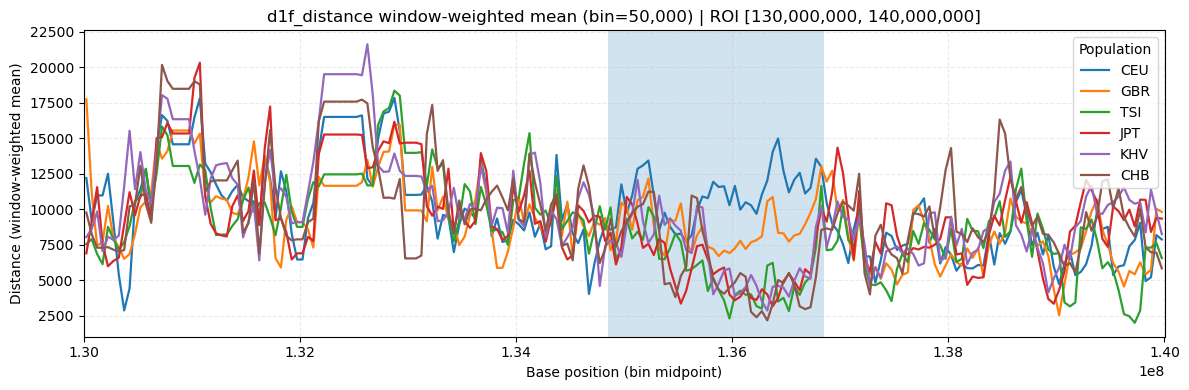

In [ ]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.3e8)
ROI_R = int(1.4e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_00

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the LCT highlight if it falls in ROI (it does)
pos = 135_851_076
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

In [5]:
# -----------------------------------
# Restrict to region of interest
# -----------------------------------
ROI_L = int(1.0e8)
ROI_R = int(1.1e8)

dfs_roi = {}
for pop, df in dfs.items():
    # keep segments that overlap the ROI at all
    d = df[(df["right"] > ROI_L) & (df["left"] < ROI_R)].copy()
    # clip segment endpoints to ROI so binning weights are correct near boundaries
    d["left"] = np.maximum(d["left"].to_numpy(dtype=float), ROI_L)
    d["right"] = np.minimum(d["right"].to_numpy(dtype=float), ROI_R)
    d = d[d["right"] > d["left"]]
    dfs_roi[pop] = d

# -----------------------------------
# Window-weighted binning (200,000 bp)
# -----------------------------------
bin_size = 200_000

# use ROI bounds (snapped to bin edges)
x0 = (ROI_L // bin_size) * bin_size
x1 = int(np.ceil(ROI_R / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def bin_df(df: pd.DataFrame):
    seg_left = df["left"].to_numpy(dtype=float)
    seg_right = df["right"].to_numpy(dtype=float)
    seg_val = df[dist_col].to_numpy(dtype=float)

    binned = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            binned[i] = np.sum(w * seg_val[m]) / np.sum(w)

    mask = np.isfinite(binned)
    return bin_mid[mask], binned[mask]

# -----------
# Plot (lines) just for ROI
# -----------
fig, ax = plt.subplots(figsize=(12, 4))

# Optional: keep the EDAR highlight if it falls in ROI (it does)
pos = 108_897_145
half = 1_000_000
L = max(pos - half, ROI_L)
R = min(pos + half, ROI_R)
if L < R:
    ax.axvspan(L, R, alpha=0.2)

# EDAR highlight does NOT fall in this ROI, so we skip it automatically

for pop, df in dfs_roi.items():
    if len(df) == 0:
        continue
    x_plot, y_plot = bin_df(df)
    ax.plot(x_plot, y_plot, linewidth=1.6, label=pop)

ax.set_xlim(ROI_L, ROI_R)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("Distance (window-weighted mean)")
ax.set_title(f"{dist_col} window-weighted mean (bin={bin_size:,}) | ROI [{ROI_L:,}, {ROI_R:,}]")
ax.grid(alpha=0.25, linestyle="--")
ax.legend(title="Population")
fig.tight_layout()
plt.show()

AttributeError: 'list' object has no attribute 'items'

## Line plot of Location vs distance to the population-specific weighted reference, by population.

This section replicates the location-vs-distance line plot workflow, but uses the revised per-population files:
`chr2_50samples_<POP>_d1f_per_tree_weighted_ref.csv`.


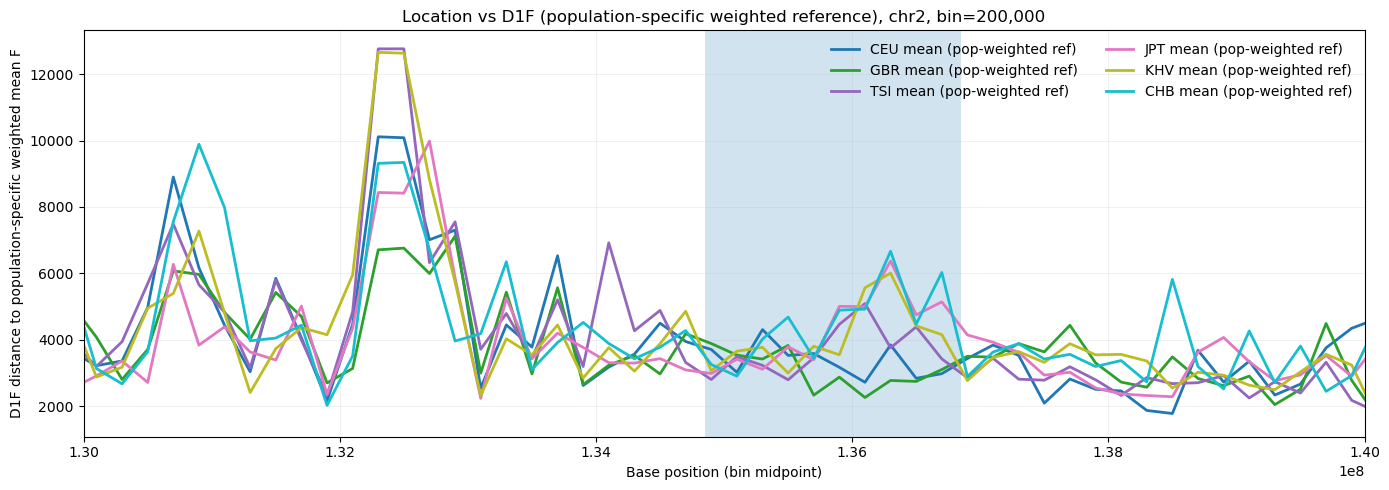

Loaded populations: CEU, GBR, TSI, JPT, KHV, CHB
CEU rows: 6857
GBR rows: 6844
TSI rows: 8168
JPT rows: 7881
KHV rows: 8066
CHB rows: 7769


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# User-configurable settings
# --------------------------
chrom = 2
selected_pops_weighted = ["CEU", "GBR", "TSI", "JPT", "KHV", "CHB"]  # set any populations you want to plot
bin_size_weighted = 200_000
# region_weighted = (90_000_000, 160_000_000)  # set to None to use full available span
region_weighted = (130_000_000, 140_000_000)

results_dir = Path('results')

def load_weighted_ref_per_pop(pop: str, chrom: int = 2) -> pd.DataFrame:
    p = results_dir / f'chr{chrom}_50samples_{pop}_d1f_per_tree_weighted_ref.csv'
    if not p.exists():
        raise FileNotFoundError(f'Missing weighted-reference file for {pop}: {p}')

    df = pd.read_csv(p)

    need = ['left', 'right', 'mid', 'd1f_distance']
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f'{p}: missing required columns {missing}')

    out = df[['left', 'right', 'mid', 'd1f_distance']].copy()
    out['window_size'] = out['right'] - out['left']
    out['population'] = pop

    # Optional region filter
    if region_weighted is not None:
        L0, R0 = region_weighted
        out = out[(out['right'] > L0) & (out['left'] < R0)].copy()

    return out.sort_values('left').reset_index(drop=True)

def binned_weighted_mean_distance(df: pd.DataFrame, bin_left: np.ndarray, bin_right: np.ndarray) -> np.ndarray:
    out = np.full(len(bin_left), np.nan, dtype=float)
    seg_left = df['left'].to_numpy(float)
    seg_right = df['right'].to_numpy(float)
    seg_d = df['d1f_distance'].to_numpy(float)

    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        mask = overlap > 0
        if np.any(mask):
            w = overlap[mask]
            out[i] = np.average(seg_d[mask], weights=w)

    return out

# Load all selected populations
pop_dfs_weighted = {pop: load_weighted_ref_per_pop(pop, chrom=chrom) for pop in selected_pops_weighted}

# Shared bin edges across selected populations
x0 = min(df['left'].min() for df in pop_dfs_weighted.values())
x1 = max(df['right'].max() for df in pop_dfs_weighted.values())
x0 = (int(x0) // bin_size_weighted) * bin_size_weighted
x1 = int(np.ceil(x1 / bin_size_weighted) * bin_size_weighted)

bin_edges_weighted = np.arange(x0, x1 + bin_size_weighted, bin_size_weighted, dtype=np.int64)
bin_left_weighted = bin_edges_weighted[:-1]
bin_right_weighted = bin_edges_weighted[1:]
bin_mid_weighted = (bin_left_weighted + bin_right_weighted) / 2.0

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(selected_pops_weighted))))

for color, pop in zip(colors, selected_pops_weighted):
    d = pop_dfs_weighted[pop]
    y = binned_weighted_mean_distance(d, bin_left_weighted, bin_right_weighted)
    mask = np.isfinite(y)
    ax.plot(bin_mid_weighted[mask], y[mask], color=color, linewidth=2.0, label=f'{pop} mean (pop-weighted ref)')

if region_weighted is not None:
    ax.set_xlim(region_weighted)

    # LCT LP canonical site (hg38 rs4988235) ~135,851,076
pos = 135_851_076
half = 1_000_000  # +/- 1 Mb
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance to population-specific weighted mean F')
ax.set_title(f'Location vs D1F (population-specific weighted reference), chr{chrom}, bin={bin_size_weighted:,}')
ax.grid(alpha=0.2, linewidth=0.6)
ax.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.show()

print('Loaded populations:', ', '.join(selected_pops_weighted))
for pop in selected_pops_weighted:
    print(pop, 'rows:', len(pop_dfs_weighted[pop]))


## $F_{ST}^{Tree}$ Statsitic Analysis

### Idea

($F_{ST}^{\text{tree}}$) measures **how much the distribution of genealogical trees differs between two populations**, analogous to how classical ($F_{ST}$) measures allele-frequency differentiation.

Instead of comparing allele frequencies, we compare **local genealogies** using a tree distance (e.g., D1F, F-matrix (L_1/L_2)).

---

### Setup

At a genomic window (b):

* Population A: trees (${T_1^A, \dots, T_m^A}$)
* Population B: trees (${T_1^B, \dots, T_m^B}$)

Let ($d(\cdot,\cdot)$) be your tree distance (e.g., D1F).

---

### Step 1 — Compute Centers (Fréchet means or medoids)

$$
\mu_A = \arg\min_t \frac{1}{m} \sum_{i=1}^m d(T_i^A, t)^2
$$
$$
\mu_B = \arg\min_t \frac{1}{m} \sum_{i=1}^m d(T_i^B, t)^2
$$

Also compute the pooled center:
$$
\mu = \arg\min_t \frac{1}{2m} \sum_{T \in A \cup B} d(T, t)^2
$$

---

### Step 2 — Compute Variances

**Within-population variance**
$$
V_W = \frac{1}{2}\left(
\frac{1}{m}\sum d(T_i^A,\mu_A)^2
+
\frac{1}{m}\sum d(T_i^B,\mu_B)^2
\right)
$$

**Total variance**
$$
V_T = \frac{1}{2m}\sum_{T \in A\cup B} d(T,\mu)^2
$$

---

### Step 3 — Define the Statistic

$$
F_{ST}^{\text{tree}} = 1 - \frac{V_W}{V_T}
$$

---

### Interpretation

* **≈ 0** → Tree distributions are similar between populations
* **Large value** → Tree distributions differ systematically
* Measures the **fraction of total tree variation explained by population labels**

Equivalent interpretation:

$$
F_{ST}^{\text{tree}} = \frac{\text{between-population tree variance}}{\text{total tree variance}}
$$

---

### Why It Detects Selection

If a selective sweep occurs in one population:

* Genealogies near the selected site become distorted
* That population’s tree distribution shifts
* Between-population variance increases
* ($F_{ST}^{\text{tree}}$) rises locally

---

### Summary

Classical ($F_{ST}$):

> Differentiation in allele frequencies

Tree ($F_{ST}$):

> Differentiation in genealogical structure (topology + branch lengths)

It is a **tree-space analogue of ($F_{ST}$)**.

,chromosome,pop_A,pop_B,V_A_within,V_B_within,V_within,V_total,FST_tree_raw,FST_tree_clipped
0,2,CEU,JPT,3460.704919,3868.408852,3664.556885,3758.799864,0.025073,0.025073


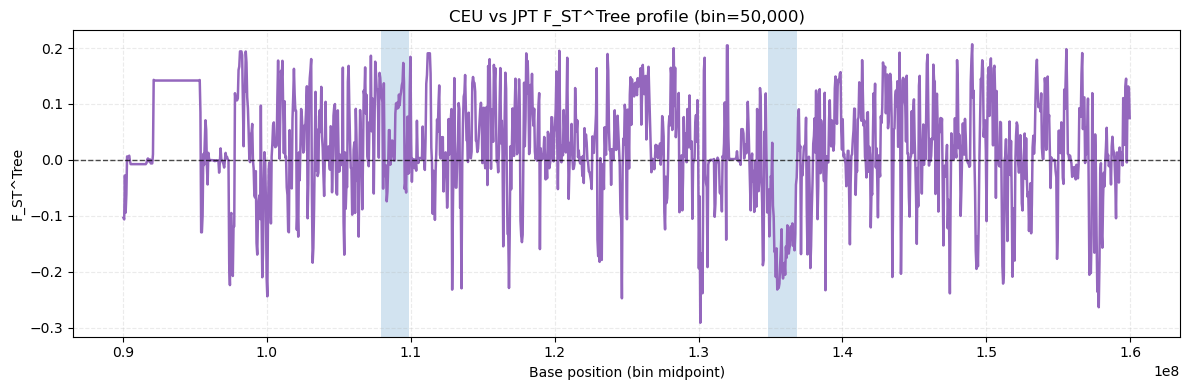

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CEU/JPT F_ST^Tree using:
# - within distances: per-pop weighted-reference D1F
# - total distances : grouped-reference D1F (CEU+JPT grouped weighted mean F)

chrom = 2
pops = ["CEU", "JPT"]
results_dir = Path("results")
bin_size_fst = 50_000


def load_within(pop: str) -> pd.DataFrame:
    p = results_dir / f"chr{chrom}_50samples_{pop}_d1f_per_tree_weighted_ref.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing within-distance CSV for {pop}: {p}")

    df = pd.read_csv(p)
    if "window_size" not in df.columns:
        if not {"left", "right"}.issubset(df.columns):
            raise KeyError(f"{p}: missing left/right and window_size")
        df["window_size"] = df["right"] - df["left"]

    need = ["left", "right", "d1f_distance", "window_size"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise KeyError(f"{p}: missing columns {miss}")

    out = df[need].copy()
    out[need] = out[need].apply(pd.to_numeric, errors="coerce")
    out = out.dropna(subset=need)
    out = out[out["window_size"] > 0]
    return out.sort_values("left").reset_index(drop=True)


def load_total(pop: str) -> pd.DataFrame:
    p = results_dir / f"chr{chrom}_50samples_{pop}_d1f_per_tree_grouped_ref.csv"
    if not p.exists():
        raise FileNotFoundError(
            f"Missing grouped-reference CSV for {pop}: {p}. Run chr2_50samples_d1f.Rmd grouped-ref chunk first."
        )

    df = pd.read_csv(p)
    if "window_size" not in df.columns:
        if not {"left", "right"}.issubset(df.columns):
            raise KeyError(f"{p}: missing left/right and window_size")
        df["window_size"] = df["right"] - df["left"]

    need = ["left", "right", "d1f_distance", "window_size"]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise KeyError(f"{p}: missing columns {miss}")

    out = df[need].copy()
    out[need] = out[need].apply(pd.to_numeric, errors="coerce")
    out = out.dropna(subset=need)
    out = out[out["window_size"] > 0]
    return out.sort_values("left").reset_index(drop=True)


def binned_weighted_mean(df: pd.DataFrame, bin_left: np.ndarray, bin_right: np.ndarray) -> np.ndarray:
    seg_left = df["left"].to_numpy(float)
    seg_right = df["right"].to_numpy(float)
    seg_val = df["d1f_distance"].to_numpy(float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)
    return out


within = {pop: load_within(pop) for pop in pops}
total = {pop: load_total(pop) for pop in pops}

V_pop = {
    pop: np.average(within[pop]["d1f_distance"], weights=within[pop]["window_size"])
    for pop in pops
}
V_within = 0.5 * (V_pop["CEU"] + V_pop["JPT"])

all_total = pd.concat([total[p] for p in pops], ignore_index=True)
V_total = np.average(all_total["d1f_distance"], weights=all_total["window_size"])

fst_tree_raw = 1.0 - (V_within / V_total)
fst_tree_clipped = max(0.0, fst_tree_raw)

summary = pd.DataFrame([
    {
        "chromosome": chrom,
        "pop_A": "CEU",
        "pop_B": "JPT",
        "V_A_within": V_pop["CEU"],
        "V_B_within": V_pop["JPT"],
        "V_within": V_within,
        "V_total": V_total,
        "FST_tree_raw": fst_tree_raw,
        "FST_tree_clipped": fst_tree_clipped,
    }
])

display(summary)

# Optional per-location profile on shared bins:
# F_ST^Tree(bin) = 1 - mean(within_CEU, within_JPT) / mean(total_CEU, total_JPT)
x0 = int(min(min(within[p]["left"].min(), total[p]["left"].min()) for p in pops))
x1 = int(max(max(within[p]["right"].max(), total[p]["right"].max()) for p in pops))
x0 = (x0 // bin_size_fst) * bin_size_fst
x1 = int(np.ceil(x1 / bin_size_fst) * bin_size_fst)

edges = np.arange(x0, x1 + bin_size_fst, bin_size_fst, dtype=np.int64)
bin_left = edges[:-1]
bin_right = edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

within_ceu = binned_weighted_mean(within["CEU"], bin_left, bin_right)
within_jpt = binned_weighted_mean(within["JPT"], bin_left, bin_right)
total_ceu = binned_weighted_mean(total["CEU"], bin_left, bin_right)
total_jpt = binned_weighted_mean(total["JPT"], bin_left, bin_right)

within_bin = 0.5 * (within_ceu + within_jpt)
total_bin = 0.5 * (total_ceu + total_jpt)

fst_bin = 1.0 - (within_bin / total_bin)
mask = np.isfinite(fst_bin) & np.isfinite(bin_mid) & (total_bin > 0)

fig, ax = plt.subplots(figsize=(12, 4))
# LCT LP canonical site (hg38 rs4988235) ~135,851,076
pos = 135_851_076
half = 1_000_000  # +/- 1 Mb
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

ax.plot(bin_mid[mask], fst_bin[mask], color="tab:purple", linewidth=1.8)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("F_ST^Tree")
ax.set_title(f"CEU vs JPT F_ST^Tree profile (bin={bin_size_fst:,})")
ax.grid(alpha=0.25, linestyle="--")
fig.tight_layout()
plt.show()



Saved segment p-values: results\chr2_ceu_jpt_fst_tree_changepoint_pvalues.csv


,segment,left,right,mid,segment_mean,n_points,p_value,q_value_bh
0,chr2_CEU_JPT_fst_seg.0,100000000.0,125200000.0,112600000.0,0.029024,504,0.073269,0.136071
1,chr2_CEU_JPT_fst_seg.1,125200000.0,126600000.0,125900000.0,0.124472,28,0.005688,0.024648
2,chr2_CEU_JPT_fst_seg.2,126600000.0,130000000.0,128300000.0,0.029241,68,0.426084,0.553909
3,chr2_CEU_JPT_fst_seg.3,130000000.0,130300000.0,130150000.0,-0.193618,6,0.001408,0.009153
4,chr2_CEU_JPT_fst_seg.4,130300000.0,135200000.0,132750000.0,-0.004327,98,0.606359,0.716606


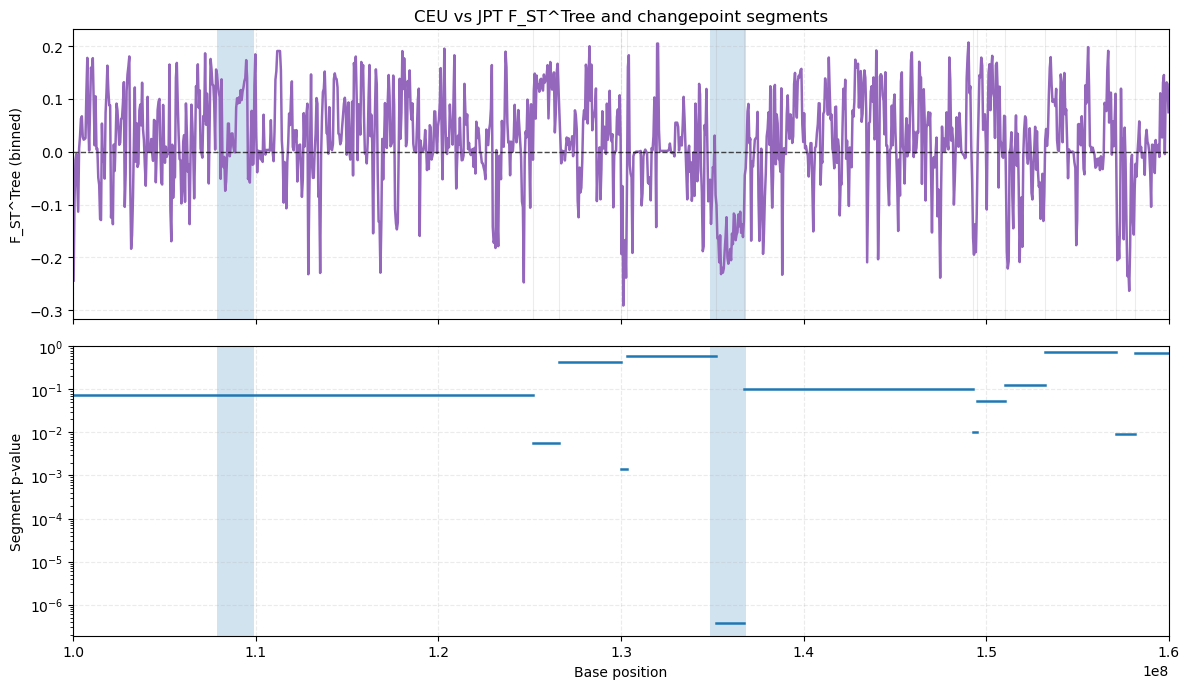

In [3]:
# Changepoint-based p-values for CEU/JPT F_ST^Tree profile
# Mirrors Analysis/Calculation.ipynb workflow:
# 1) KernelCPD segmentation
# 2) lag-covariance estimate
# 3) segment-level p-values from weighted means

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import ruptures as rpt
from pathlib import Path

# -------------------------
# Settings
# -------------------------
CP_KERNEL = 'linear'
CP_AVG_SEGMENT_BP = 5_000_000   # target average segment length in bp
CP_MAX_LAG = 5
CP_WEIGHTS = 'gaussian'         # gaussian / uniform / linear
CP_TWO_SIDED_PVALUE = True
CP_OUTPUT = Path('results') / 'chr2_ceu_jpt_fst_tree_changepoint_pvalues.csv'

# Region of interest for changepoint analysis and visualization.
# Set to None for full range, or (left, right) e.g. (130_000_000, 140_000_000).
#CP_ROI =  (110_000_000, 160_000_000)
CP_ROI = (100_000_000, 160_000_000)

# -------------------------
# Build signal table from previous F_ST^Tree cell
# -------------------------
if 'bin_mid' not in globals() or 'fst_bin' not in globals() or 'mask' not in globals():
    raise RuntimeError('Run the CEU/JPT F_ST^Tree cell first (needs bin_mid, fst_bin, mask).')

x = np.asarray(bin_mid)[np.asarray(mask)]
y = np.asarray(fst_bin)[np.asarray(mask)]

ok = np.isfinite(x) & np.isfinite(y)
x = x[ok]
y = y[ok]

if len(x) < 6:
    raise ValueError(f'Not enough valid F_ST^Tree bins for changepoint analysis: n={len(x)}')

# Reconstruct bin boundaries from consecutive midpoints (works for uniform binning)
if len(x) > 1:
    dx = float(np.median(np.diff(np.sort(x))))
else:
    dx = float(bin_size_fst)

left = x - dx / 2.0
right = x + dx / 2.0

df_cp = pd.DataFrame({
    'mid': x,
    'left': left,
    'right': right,
    'fst_tree': y,
}).sort_values('mid').reset_index(drop=True)

if CP_ROI is not None:
    roi_left, roi_right = CP_ROI
    if roi_right <= roi_left:
        raise ValueError(f'Invalid CP_ROI: {CP_ROI}. Expected (left, right) with right > left.')

    # Keep bins overlapping ROI and clip boundaries for display consistency
    df_cp = df_cp[(df_cp['right'] > roi_left) & (df_cp['left'] < roi_right)].copy()
    df_cp['left'] = np.maximum(df_cp['left'].to_numpy(float), float(roi_left))
    df_cp['right'] = np.minimum(df_cp['right'].to_numpy(float), float(roi_right))
    df_cp = df_cp[df_cp['right'] > df_cp['left']].reset_index(drop=True)

if len(df_cp) < 6:
    raise ValueError(f'Not enough bins after ROI filter for changepoint analysis: n={len(df_cp)}, CP_ROI={CP_ROI}')

# -------------------------
# Helper functions (adapted from Analysis/Calculation.ipynb)
# -------------------------
def _lag_cov(arr, lag):
    arr = np.asarray(arr, dtype=float)
    if lag <= 0:
        return np.cov(arr, arr)[0, 1]
    if lag >= len(arr):
        return 0.0
    return np.cov(arr[lag:], arr[:-lag])[0, 1]


def gaussian_weights(n):
    w = np.arange(1, n + 1)
    m = (n + 1) / 2.0
    w = norm.pdf(5 * (w - m) / (n + 1))
    return w / w.sum()


def linear_weights(n):
    w = np.arange(n)
    w = np.minimum(n - w, w + 1)
    return w / w.sum()


def uniform_weights(n):
    w = np.ones(n)
    return w / w.sum()


def segment_signal(signal, n_bkps, kernel='linear'):
    signal = np.asarray(signal, dtype=float)
    s = signal.std()
    s = s if s > 0 else 1.0
    algo = rpt.KernelCPD(kernel=kernel).fit(signal / s)
    bkps = algo.predict(n_bkps=n_bkps)
    bkps = np.r_[0, bkps]
    labels = np.repeat(np.arange(len(bkps) - 1), np.diff(bkps))
    return labels


def segment_pvalues(df, signal_col, seg_col, mu_g, cov, weights='gaussian'):
    def _weights(n):
        if weights == 'linear':
            return linear_weights(n)
        if weights == 'uniform':
            return uniform_weights(n)
        return gaussian_weights(n)

    def _segment_p(x):
        x = np.asarray(x, dtype=float)
        w = _weights(len(x))
        x_bar = float((x * w).sum())

        w2 = w ** 2
        x_bar_var = float(w2.sum() * cov[0])
        for i in range(1, len(x)):
            if i < len(cov):
                cW = float((w[:-i] * w[i:]).sum())
                x_bar_var += float(2.0 * cov[i] * cW)

        sem = np.sqrt(x_bar_var) if x_bar_var > 0 else np.nan
        if not np.isfinite(sem):
            return np.nan
        z = (x_bar - mu_g) / sem
        if CP_TWO_SIDED_PVALUE:
            return 2.0 * (1.0 - norm.cdf(abs(z)))
        return 1.0 - norm.cdf(z)

    out = (
        df.groupby(seg_col, sort=False)
          .agg(
              left=('left', 'first'),
              right=('right', 'last'),
              mid=('mid', 'mean'),
              segment_mean=(signal_col, 'mean'),
              n_points=(signal_col, 'size'),
          )
          .reset_index()
    )

    pvals = (
        df.groupby(seg_col, sort=False)[signal_col]
          .apply(lambda s: _segment_p(s.to_numpy()))
          .to_numpy()
    )
    out['p_value'] = pvals
    return out

# -------------------------
# Segmentation and p-values
# -------------------------
span = float(df_cp['right'].max() - df_cp['left'].min())
n_bkps = max(1, int(round(span / CP_AVG_SEGMENT_BP)))
n_bkps = min(n_bkps, max(1, len(df_cp) - 2))

labels = segment_signal(df_cp['fst_tree'].to_numpy(), n_bkps=n_bkps, kernel=CP_KERNEL)
df_cp['segment'] = [f'chr2_CEU_JPT_fst_seg.{i}' for i in labels]

mu_g = float(df_cp['fst_tree'].mean())
cov = np.array([_lag_cov(df_cp['fst_tree'].to_numpy(), k) for k in range(CP_MAX_LAG)], dtype=float)

segment_df_fst = segment_pvalues(
    df_cp,
    signal_col='fst_tree',
    seg_col='segment',
    mu_g=mu_g,
    cov=cov,
    weights=CP_WEIGHTS,
)

# Attach BH-FDR q-values (simple Benjamini-Hochberg)
p = segment_df_fst['p_value'].to_numpy(dtype=float)
order = np.argsort(np.nan_to_num(p, nan=1.0))
ranks = np.empty_like(order)
ranks[order] = np.arange(1, len(p) + 1)
q = p * len(p) / ranks
q = np.minimum.accumulate(np.sort(q)[::-1])[::-1][np.argsort(order)]
segment_df_fst['q_value_bh'] = np.clip(q, 0, 1)

CP_OUTPUT.parent.mkdir(parents=True, exist_ok=True)
segment_df_fst.to_csv(CP_OUTPUT, index=False)
print(f'Saved segment p-values: {CP_OUTPUT}')

display(segment_df_fst.head())

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

pos = 135_851_076
half = 1_000_000
pos2 = 108_897_145
half2 = 1_000_000

for ax in axes:
    ax.axvspan(pos - half,  pos + half,  alpha=0.2)
    ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

# Top: original binned F_ST^Tree profile
axes[0].plot(df_cp['mid'], df_cp['fst_tree'], color='tab:purple', linewidth=1.8)
axes[0].axhline(0.0, color='black', linestyle='--', linewidth=1.0, alpha=0.7)
axes[0].set_ylabel('F_ST^Tree (binned)')
axes[0].set_title('CEU vs JPT F_ST^Tree and changepoint segments')
axes[0].grid(alpha=0.25, linestyle='--')

# Overlay segment boundaries
bounds = np.unique(np.r_[segment_df_fst['left'].to_numpy(), segment_df_fst['right'].to_numpy()])
for b in bounds:
    axes[0].axvline(b, color='gray', alpha=0.15, linewidth=0.8)

# Bottom: segment-level p-values
for _, row in segment_df_fst.iterrows():
    axes[1].plot([row['left'], row['right']], [row['p_value'], row['p_value']], color='tab:blue', linewidth=1.8)

axes[1].set_yscale('log')
axes[1].set_ylim(max(segment_df_fst['p_value'].min() * 0.5, 1e-12), 1)
axes[1].set_xlabel('Base position')
axes[1].set_ylabel('Segment p-value')
axes[1].grid(alpha=0.25, linestyle='--')

if CP_ROI is not None:
    axes[0].set_xlim(CP_ROI)
    axes[1].set_xlim(CP_ROI)
else:
    x_min = float(df_cp['left'].min())
    x_max = float(df_cp['right'].max())
    axes[0].set_xlim(x_min, x_max)
    axes[1].set_xlim(x_min, x_max)

plt.tight_layout()
plt.show()

## Line plot of base-pair location (midpoint) vs D1FW, by population

This section plots the new per-population D1FW outputs from `chr2_50samples_d1fw.Rmd`:
`chr2_50samples_<POP>_d1fw_per_tree.csv`.


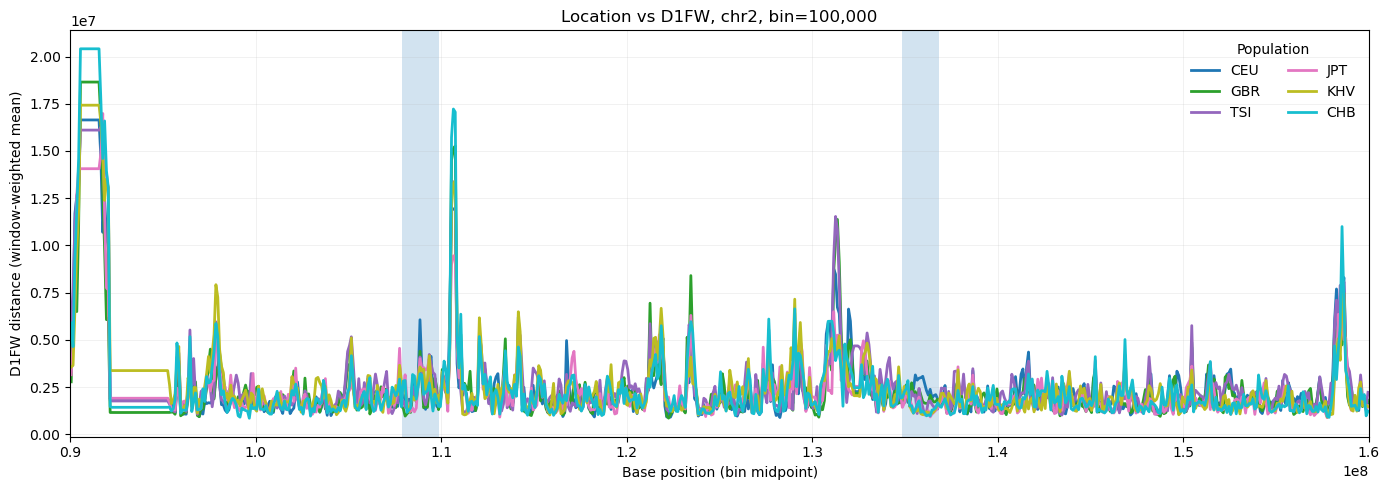

Loaded populations: CEU, GBR, TSI, JPT, KHV, CHB
CEU rows: 49279
GBR rows: 49068
TSI rows: 53781
JPT rows: 50253
KHV rows: 49921
CHB rows: 49164


In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------
# User-configurable settings
# --------------------------
chrom_d1fw = 2
selected_pops_d1fw = ["CEU", "GBR", "TSI", "JPT", "KHV", "CHB"]
bin_size_d1fw = 100_000
# region_d1fw = None
region_d1fw = (90_000_000, 160_000_000)

results_dir = Path("results")

def load_d1fw_per_pop(pop: str, chrom: int = 2) -> pd.DataFrame:
    p = results_dir / f"chr{chrom}_50samples_{pop}_d1fw_per_tree_weighted_ref.csv"
    if not p.exists():
        raise FileNotFoundError(f"Missing D1FW file for {pop}: {p}")

    df = pd.read_csv(p)
    need = ["left", "right", "mid", "d1fw_distance"]
    missing = [c for c in need if c not in df.columns]
    if missing:
        raise KeyError(f"{p}: missing required columns {missing}")

    out = df[need].copy()
    if region_d1fw is not None:
        L0, R0 = region_d1fw
        out = out[(out["right"] > L0) & (out["left"] < R0)].copy()

    out = out.sort_values("left").reset_index(drop=True)
    return out

def binned_weighted_mean_d1fw(df: pd.DataFrame, bin_left: np.ndarray, bin_right: np.ndarray) -> np.ndarray:
    out = np.full(len(bin_left), np.nan, dtype=float)
    seg_left = df["left"].to_numpy(float)
    seg_right = df["right"].to_numpy(float)
    seg_d = df["d1fw_distance"].to_numpy(float)

    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        mask = overlap > 0
        if np.any(mask):
            w = overlap[mask]
            out[i] = np.average(seg_d[mask], weights=w)

    return out

pop_dfs_d1fw = {pop: load_d1fw_per_pop(pop, chrom=chrom_d1fw) for pop in selected_pops_d1fw}

x0 = min(df["left"].min() for df in pop_dfs_d1fw.values())
x1 = max(df["right"].max() for df in pop_dfs_d1fw.values())
x0 = (int(x0) // bin_size_d1fw) * bin_size_d1fw
x1 = int(np.ceil(x1 / bin_size_d1fw) * bin_size_d1fw)

bin_edges_d1fw = np.arange(x0, x1 + bin_size_d1fw, bin_size_d1fw, dtype=np.int64)
bin_left_d1fw = bin_edges_d1fw[:-1]
bin_right_d1fw = bin_edges_d1fw[1:]
bin_mid_d1fw = (bin_left_d1fw + bin_right_d1fw) / 2.0

fig, ax = plt.subplots(figsize=(14, 5))
colors = plt.cm.tab10(np.linspace(0, 1, max(1, len(selected_pops_d1fw))))

for color, pop in zip(colors, selected_pops_d1fw):
    d = pop_dfs_d1fw[pop]
    y = binned_weighted_mean_d1fw(d, bin_left_d1fw, bin_right_d1fw)
    mask = np.isfinite(y)
    ax.plot(bin_mid_d1fw[mask], y[mask], color=color, linewidth=2.0, label=pop)

if region_d1fw is not None:
    ax.set_xlim(region_d1fw)

pos = 135_851_076
half = 1_000_000
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("D1FW distance (window-weighted mean)")
ax.set_title(f"Location vs D1FW, chr{chrom_d1fw}, bin={bin_size_d1fw:,}")
ax.grid(alpha=0.2, linewidth=0.6)
ax.legend(frameon=False, ncol=2, title="Population")
plt.tight_layout()
plt.show()

print("Loaded populations:", ", ".join(selected_pops_d1fw))
for pop in selected_pops_d1fw:
    print(pop, "rows:", len(pop_dfs_d1fw[pop]))


## CEU vs JPT: Binned D1F between population-average F matrices

Loads the binned output from `chr2_50samples_d1f.Rmd` and plots D1F distance between CEU and JPT weighted-average F-matrices by genomic location.

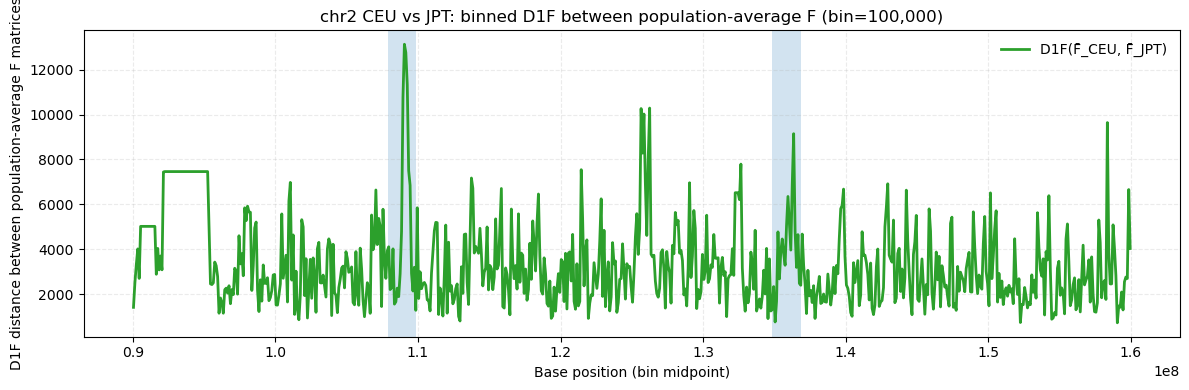

Loaded: results\chr2_50samples_CEU_JPT_d1f_between_pop_binned_bin100000.csv
Bins plotted: 700 / 700


In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------
# User-configurable settings
# --------------------------
chrom_pair = 2
pop_a = "CEU"
pop_b = "JPT"
bin_size_pair = 100_000
region_pair = None  # e.g. (90_000_000, 160_000_000)

results_dir = Path("results")
pair_csv = results_dir / f"chr{chrom_pair}_50samples_{pop_a}_{pop_b}_d1f_between_pop_binned_bin{bin_size_pair}.csv"

if not pair_csv.exists():
    raise FileNotFoundError(
        f"Missing binned CEU/JPT file: {pair_csv}. Run the new binned chunk in chr2_50samples_d1f.Rmd first."
    )

pair_df = pd.read_csv(pair_csv)
required = ["bin_left", "bin_right", "bin_mid", "d1f_distance_between_pops"]
missing = [c for c in required if c not in pair_df.columns]
if missing:
    raise KeyError(f"{pair_csv}: missing required columns {missing}")

for c in required:
    pair_df[c] = pd.to_numeric(pair_df[c], errors="coerce")

pair_df = pair_df.dropna(subset=required).sort_values("bin_left").reset_index(drop=True)

if region_pair is not None:
    L0, R0 = region_pair
    pair_df = pair_df[
        (pair_df["bin_right"] > L0) & (pair_df["bin_left"] < R0)
    ].copy()

mask = np.isfinite(pair_df["d1f_distance_between_pops"].to_numpy(float))

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    pair_df.loc[mask, "bin_mid"],
    pair_df.loc[mask, "d1f_distance_between_pops"],
    color="tab:green",
    linewidth=2.0,
    label=f"D1F(F̄_{pop_a}, F̄_{pop_b})"
)

pos = 135_851_076
half = 1_000_000
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("D1F distance between population-average F matrices")
ax.set_title(
    f"chr{chrom_pair} {pop_a} vs {pop_b}: "
    f"binned D1F between population-average F (bin={bin_size_pair:,})"
)

ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

print(f"Loaded: {pair_csv}")
print(f"Bins plotted: {int(mask.sum())} / {len(mask)}")

## Plot all-population 2-individual D1F vs genomic location

This chunk reads the CSV produced by `chr2_2inds_allpops_d1f.Rmd` and plots per-tree distance against genomic midpoint. Sampled 2 individuals from each population.


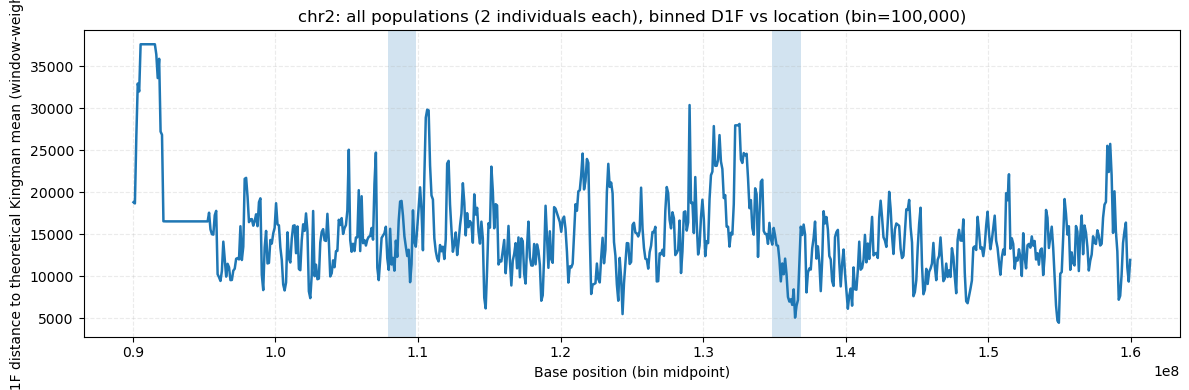

Loaded rows: 104960
Binned points: 700
Input file: results\chr2_2inds_allpops_d1f_per_tree.csv


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path('results')
CHR_ALLPOPS_2 = 2
bin_size = 100_000

csv_path = results_dir / f'chr{CHR_ALLPOPS_2}_2inds_allpops_d1f_per_tree.csv'
if not csv_path.exists():
    raise FileNotFoundError(f'Missing all-population D1F CSV: {csv_path}')

df_allpops = pd.read_csv(csv_path)

required_cols = ['left', 'right', 'mid', 'd1f_distance']
missing_cols = [c for c in required_cols if c not in df_allpops.columns]
if missing_cols:
    raise KeyError(f'{csv_path.name}: missing required columns {missing_cols}')

df_allpops = df_allpops.copy()
for c in required_cols:
    df_allpops[c] = pd.to_numeric(df_allpops[c], errors='coerce')

df_allpops = df_allpops.dropna(subset=required_cols)
df_allpops = df_allpops[df_allpops['right'] > df_allpops['left']].sort_values('left').reset_index(drop=True)

if len(df_allpops) == 0:
    raise ValueError('No valid rows remain after numeric coercion and interval filtering.')

x0 = int(df_allpops['left'].min())
x1 = int(df_allpops['right'].max())
x0 = (x0 // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

seg_left = df_allpops['left'].to_numpy(float)
seg_right = df_allpops['right'].to_numpy(float)
seg_d = df_allpops['d1f_distance'].to_numpy(float)

binned = np.full(len(bin_left), np.nan, dtype=float)

for i, (L, R) in enumerate(zip(bin_left, bin_right)):
    overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
    mask = overlap > 0
    if np.any(mask):
        w = overlap[mask]
        binned[i] = np.average(seg_d[mask], weights=w)

mask = np.isfinite(binned)

fig, ax = plt.subplots(figsize=(12, 4))
pos = 135_851_076
half = 1_000_000
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)
ax.plot(bin_mid[mask], binned[mask], linewidth=1.8)
ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance to theoretical Kingman mean (window-weighted)')
ax.set_title(f'chr{CHR_ALLPOPS_2}: all populations (2 individuals each), binned D1F vs location (bin={bin_size:,})')
ax.grid(alpha=0.25, linestyle='--')
fig.tight_layout()
plt.show()

print('Loaded rows:', len(df_allpops))
print('Binned points:', int(mask.sum()))
print('Input file:', csv_path)


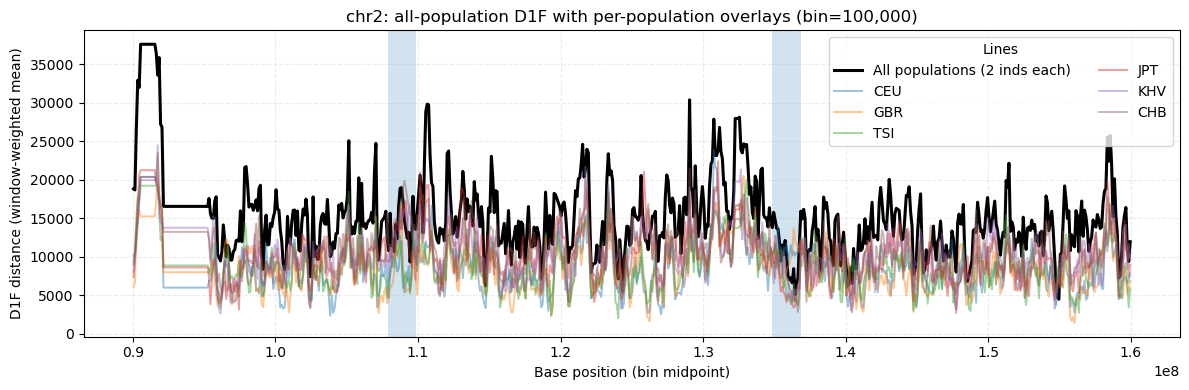

In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path('results')
CHR_ALLPOPS_2 = 2
bin_size = 100_000
num_samples = 52

allpops_csv = results_dir / f'chr{CHR_ALLPOPS_2}_2inds_allpops_d1f_per_tree.csv'
if not allpops_csv.exists():
    raise FileNotFoundError(f'Missing all-population D1F CSV: {allpops_csv}')

df_allpops = pd.read_csv(allpops_csv)
required_allpops = ['left', 'right', 'd1f_distance']
missing_allpops = [c for c in required_allpops if c not in df_allpops.columns]
if missing_allpops:
    raise KeyError(f'{allpops_csv.name}: missing columns {missing_allpops}')

for c in required_allpops:
    df_allpops[c] = pd.to_numeric(df_allpops[c], errors='coerce')

df_allpops = df_allpops.dropna(subset=required_allpops)
df_allpops = df_allpops[df_allpops['right'] > df_allpops['left']].sort_values('left').reset_index(drop=True)
if len(df_allpops) == 0:
    raise ValueError('No valid all-population rows remain after filtering.')

target_pops = ['CEU', 'GBR', 'TSI', 'JPT', 'KHV', 'CHB']
per_pop_paths = {pop: results_dir / f'chr{CHR_ALLPOPS_2}_{num_samples}samples_{pop}_d1f_per_tree.csv' for pop in target_pops}

missing_pops = [pop for pop, path in per_pop_paths.items() if not path.exists()]
if missing_pops:
    raise FileNotFoundError(
        'Missing per-population D1F CSV(s): '
        + ', '.join(f'{pop} ({per_pop_paths[pop].name})' for pop in missing_pops)
    )

dfs = {pop: pd.read_csv(path) for pop, path in per_pop_paths.items()}
dist_candidates = ['distance', 'd1f_distance', 'dif_distance']
dist_col = next((c for c in dist_candidates if c in next(iter(dfs.values())).columns), None)
if dist_col is None:
    raise KeyError('No distance column found in per-population files. Tried: ' + ', '.join(dist_candidates))

def clean_df(df: pd.DataFrame, distance_col: str) -> pd.DataFrame:
    needed = ['left', 'right', distance_col]
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f'missing columns {missing}')

    out = df.copy()
    for c in needed:
        out[c] = pd.to_numeric(out[c], errors='coerce')

    out = out.dropna(subset=needed)
    out = out[out['right'] > out['left']]
    out = out.sort_values('left').reset_index(drop=True)
    return out

df_allpops = clean_df(df_allpops, 'd1f_distance')
for pop in target_pops:
    dfs[pop] = clean_df(dfs[pop], dist_col)

x0 = min([int(df_allpops['left'].min())] + [int(df['left'].min()) for df in dfs.values()])
x1 = max([int(df_allpops['right'].max())] + [int(df['right'].max()) for df in dfs.values()])
x0 = (x0 // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

def binned_weighted_curve(df: pd.DataFrame, distance_col: str):
    seg_left = df['left'].to_numpy(dtype=float)
    seg_right = df['right'].to_numpy(dtype=float)
    seg_val = df[distance_col].to_numpy(dtype=float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)

    m = np.isfinite(out)
    return bin_mid[m], out[m]

fig, ax = plt.subplots(figsize=(12, 4))

pos = 135_851_076
half = 1_000_000
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

x_all, y_all = binned_weighted_curve(df_allpops, 'd1f_distance')
ax.plot(x_all, y_all, linewidth=2.2, color='black', label='All populations (2 inds each)')

for pop in target_pops:
    x_pop, y_pop = binned_weighted_curve(dfs[pop], dist_col)
    ax.plot(x_pop, y_pop, linewidth=1.4, alpha=0.45, label=pop)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance (window-weighted mean)')
ax.set_title(f'chr{CHR_ALLPOPS_2}: all-population D1F with per-population overlays (bin={bin_size:,})')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Lines', ncol=2, frameon=True)
fig.tight_layout()
plt.show()


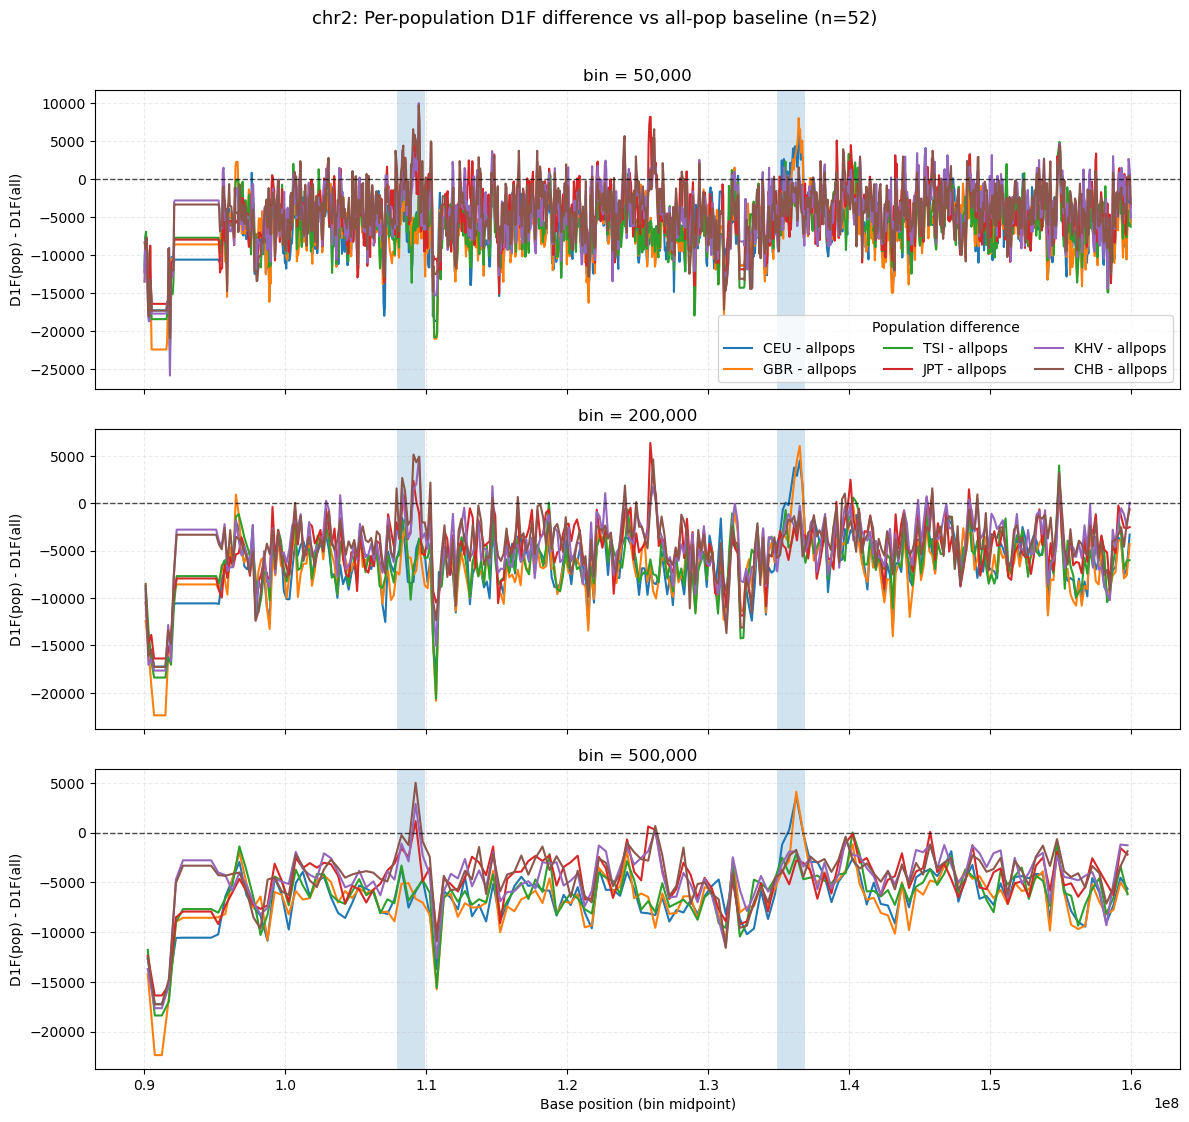

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_dir = Path('results')
CHR_ALLPOPS_2 = 2
num_samples = 52

target_pops = ['CEU', 'GBR', 'TSI', 'JPT', 'KHV', 'CHB']
bin_sizes = [50_000, 200_000, 500_000]

allpops_csv = results_dir / f'chr{CHR_ALLPOPS_2}_2inds_allpops_d1f_per_tree.csv'
per_pop_paths = {
    pop: results_dir / f'chr{CHR_ALLPOPS_2}_{num_samples}samples_{pop}_d1f_per_tree.csv'
    for pop in target_pops
}

if not allpops_csv.exists():
    raise FileNotFoundError(f'Missing all-population D1F CSV: {allpops_csv}')

missing_pops = [pop for pop, path in per_pop_paths.items() if not path.exists()]
if missing_pops:
    raise FileNotFoundError(
        'Missing per-population D1F CSV(s): '
        + ', '.join(f'{pop} ({per_pop_paths[pop].name})' for pop in missing_pops)
    )

df_allpops = pd.read_csv(allpops_csv)
dfs = {pop: pd.read_csv(path) for pop, path in per_pop_paths.items()}

pop_dist_candidates = ['distance', 'd1f_distance', 'dif_distance']
pop_dist_col = next(
    (c for c in pop_dist_candidates if c in next(iter(dfs.values())).columns),
    None
)
if pop_dist_col is None:
    raise KeyError('No distance column found in per-population files.')

def clean_df(df: pd.DataFrame, distance_col: str) -> pd.DataFrame:
    required = ['left', 'right', distance_col]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f'missing columns {missing}')

    out = df.copy()
    for c in required:
        out[c] = pd.to_numeric(out[c], errors='coerce')

    out = out.dropna(subset=required)
    out = out[out['right'] > out['left']]
    out = out.sort_values('left').reset_index(drop=True)
    return out

df_allpops = clean_df(df_allpops, 'd1f_distance')
for pop in target_pops:
    dfs[pop] = clean_df(dfs[pop], pop_dist_col)

# Determine global coordinate range once
x0 = min([int(df_allpops['left'].min())] +
         [int(df['left'].min()) for df in dfs.values()])
x1 = max([int(df_allpops['right'].max())] +
         [int(df['right'].max()) for df in dfs.values()])

# -------------------------
# Plot vertically stacked panels
# -------------------------
fig, axes = plt.subplots(
    len(bin_sizes), 1,
    figsize=(12, 3.8 * len(bin_sizes)),
    sharex=True
)

if len(bin_sizes) == 1:
    axes = [axes]

for ax, bin_size in zip(axes, bin_sizes):

    x0_bin = (x0 // bin_size) * bin_size
    x1_bin = int(np.ceil(x1 / bin_size) * bin_size)

    bin_edges = np.arange(x0_bin, x1_bin + bin_size, bin_size, dtype=np.int64)
    bin_left = bin_edges[:-1]
    bin_right = bin_edges[1:]
    bin_mid = (bin_left + bin_right) / 2.0

    def binned_weighted_on_common_bins(df: pd.DataFrame, distance_col: str) -> np.ndarray:
        seg_left = df['left'].to_numpy(dtype=float)
        seg_right = df['right'].to_numpy(dtype=float)
        seg_val = df[distance_col].to_numpy(dtype=float)

        out = np.full(len(bin_left), np.nan, dtype=float)

        for i, (L, R) in enumerate(zip(bin_left, bin_right)):
            overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
            m = overlap > 0
            if np.any(m):
                w = overlap[m]
                out[i] = np.sum(w * seg_val[m]) / np.sum(w)

        return out

    y_all = binned_weighted_on_common_bins(df_allpops, 'd1f_distance')

    for pop in target_pops:
        y_pop = binned_weighted_on_common_bins(dfs[pop], pop_dist_col)
        y_diff = y_pop - y_all
        m = np.isfinite(y_diff)
        ax.plot(bin_mid[m], y_diff[m], linewidth=1.5, label=f'{pop} - allpops')

    # Horizontal baseline
    ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)

    # Highlight regions (EDAR, LCT)
    pos1 = 135_851_076
    pos2 = 108_897_145
    half = 1_000_000

    ax.axvspan(pos1 - half, pos1 + half, alpha=0.2)
    ax.axvspan(pos2 - half, pos2 + half, alpha=0.2)

    ax.set_ylabel('D1F(pop) - D1F(all)')
    ax.set_title(f'bin = {bin_size:,}')
    ax.grid(alpha=0.25, linestyle='--')

axes[-1].set_xlabel('Base position (bin midpoint)')
axes[0].legend(title='Population difference', ncol=3, frameon=True)

fig.suptitle(
    f'chr{CHR_ALLPOPS_2}: Per-population D1F difference vs all-pop baseline (n={num_samples})',
    fontsize=13
)

fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Chr2: Population (52 samples) vs all-population (2 inds/pop) binned D1F

This section loads binned distances from `chr2_52samples_vs_allpops2inds_d1f.Rmd` and plots
`D1F(F?_population_bin, F?_allpops2inds_bin)` against genomic location.


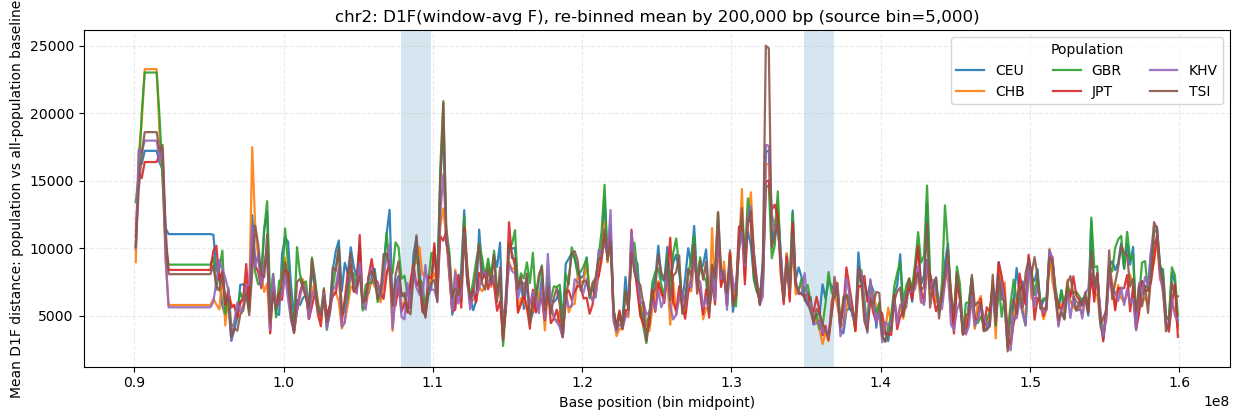

Rows loaded: 84000
Rows after overlap filter: 84000
Rows after re-binning (population x 100k bins): 2100
Input file: results\chr2_52samples_vs_allpops2inds_d1f_between_pop_binned_bin5000.csv


In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results_dir = Path('results')
CHR = 2
num_samples = 52
source_bin_size_bp = 5_000
plot_bin_size_bp = 200_000

csv_path = results_dir / f'chr{CHR}_{num_samples}samples_vs_allpops2inds_d1f_between_pop_binned_bin{source_bin_size_bp}.csv'
if not csv_path.exists():
    raise FileNotFoundError(
        f'Missing pop-vs-allpops binned CSV: {csv_path}. '
        'Run chr2_52samples_vs_allpops2inds_d1f.Rmd first.'
    )

df = pd.read_csv(csv_path)
required_cols = [
    'population', 'bin_mid', 'd1f_distance_pop_vs_allpops',
    'n_overlap_pop', 'n_overlap_allpops'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise KeyError(f'{csv_path.name}: missing required columns {missing}')

for c in ['bin_mid', 'd1f_distance_pop_vs_allpops', 'n_overlap_pop', 'n_overlap_allpops']:
    df[c] = pd.to_numeric(df[c], errors='coerce')

df = df.dropna(subset=['population', 'bin_mid', 'd1f_distance_pop_vs_allpops'])
df = df.sort_values(['population', 'bin_mid']).reset_index(drop=True)

# Keep source bins where both references had overlap.
df_plot = df[(df['n_overlap_pop'] > 0) & (df['n_overlap_allpops'] > 0)].copy()
if len(df_plot) == 0:
    raise ValueError('No bins with overlap in both population and all-population references.')

# Re-bin to larger plotting bins and average distance within each bin.
df_plot['plot_bin_left'] = (df_plot['bin_mid'] // plot_bin_size_bp).astype(np.int64) * plot_bin_size_bp
df_plot['plot_bin_mid'] = df_plot['plot_bin_left'] + (plot_bin_size_bp / 2.0)

df_plot_binned = (
    df_plot
    .groupby(['population', 'plot_bin_mid'], as_index=False)['d1f_distance_pop_vs_allpops']
    .mean()
    .sort_values(['population', 'plot_bin_mid'])
)

fig, ax = plt.subplots(figsize=(12.5, 4.3))
for pop, d in df_plot_binned.groupby('population', sort=True):
    ax.plot(
        d['plot_bin_mid'],
        d['d1f_distance_pop_vs_allpops'],
        linewidth=1.6,
        alpha=0.9,
        label=pop,
    )

pos = 135_851_076
half = 1_000_000
ax.axvspan(pos - half, pos + half, alpha=0.18)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.18)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('Mean D1F distance: population vs all-population baseline')
ax.set_title(
    f'chr{CHR}: D1F(window-avg F), re-binned mean by {plot_bin_size_bp:,} bp '
    f'(source bin={source_bin_size_bp:,})'
)
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Population', ncol=3, frameon=True)
fig.tight_layout()
plt.show()

print('Rows loaded:', len(df))
print('Rows after overlap filter:', len(df_plot))
print('Rows after re-binning (population x 100k bins):', len(df_plot_binned))
print('Input file:', csv_path)


## Chr2: Local F_ST^Tree for CEU vs all-population baseline

This section loads local/bin-wise `F_ST^Tree` calculated in
`chr2_52samples_vs_allpops2inds_d1f.Rmd` and plots it against genomic location.


,chromosome,pop_A,pop_B,V_A_within,V_B_within,V_within,V_total,FST_tree_raw,FST_tree_clipped
0,2,CEU,allpops_2inds,3879.514208,5094.92463,4487.219419,5533.025749,0.189012,0.189012


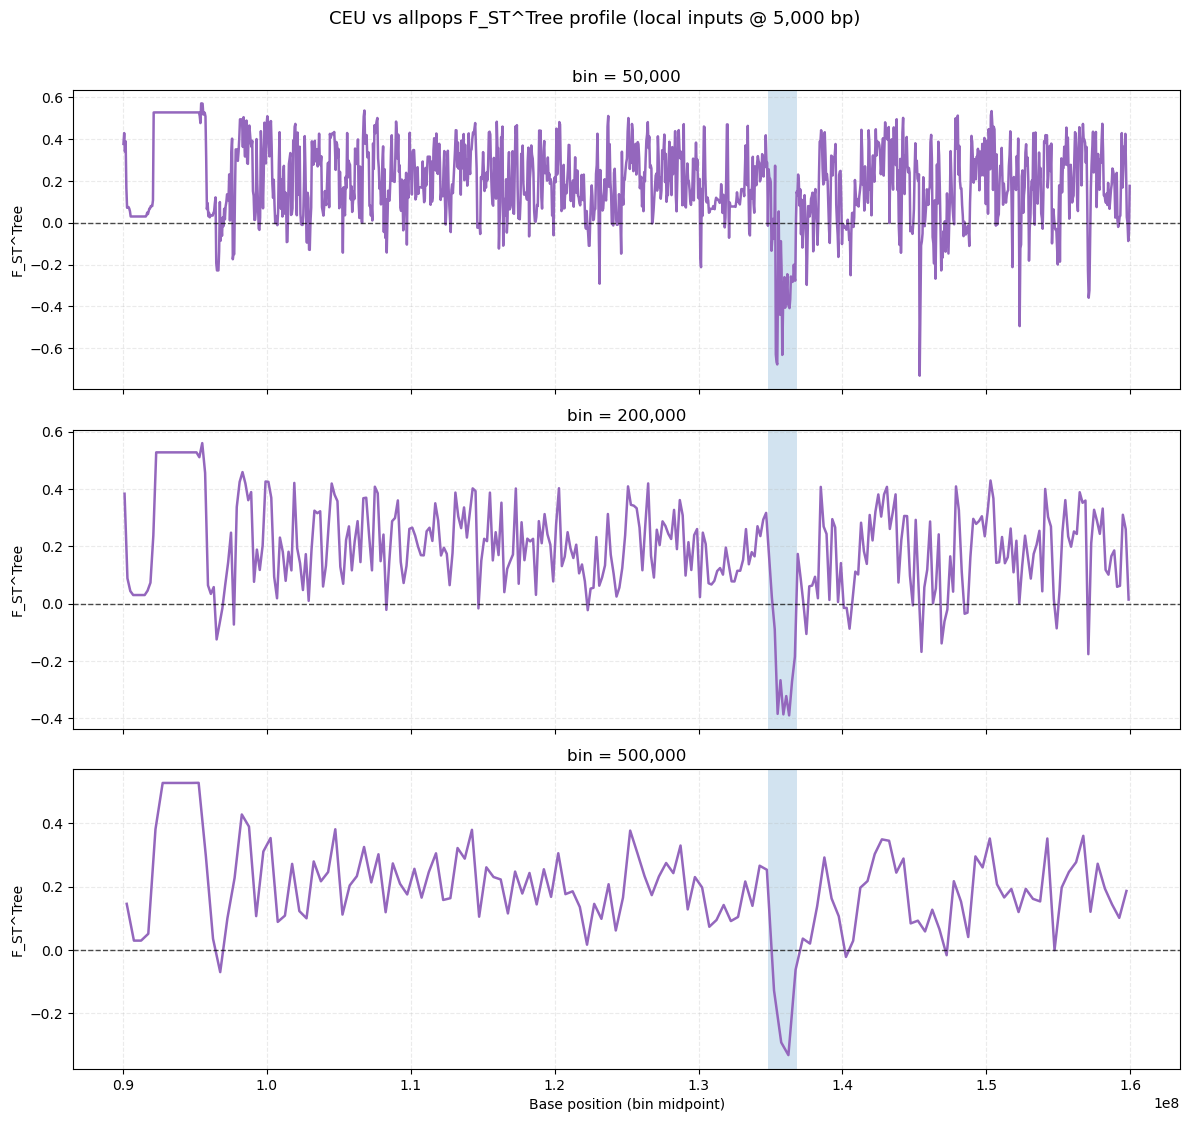

Rows loaded: 14000
Rows used for summary/profile: 14000
Input file: results\chr2_52samples_CEU_vs_allpops2inds_fst_tree_local_bin5000.csv


In [5]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CEU vs allpops F_ST^Tree using local outputs from
# chr2_52samples_vs_allpops2inds_d1f.Rmd Step 4.

chrom = 2
pop = "CEU"
baseline = "allpops_2inds"
results_dir = Path("results")
source_bin_size = 5_000
bin_sizes_fst = [50_000, 200_000, 500_000]   # <- loop over these
num_samples = 52

csv_path = results_dir / f"chr{chrom}_{num_samples}samples_{pop}_vs_allpops2inds_fst_tree_local_bin{source_bin_size}.csv"
if not csv_path.exists():
    raise FileNotFoundError(
        f"Missing local F_ST^Tree CSV: {csv_path}. "
        "Run chr2_52samples_vs_allpops2inds_d1f.Rmd Step 4 first."
    )

df = pd.read_csv(csv_path)
need = [
    "bin_left", "bin_right", "bin_mid",
    "V_pop_within", "V_allpops_within", "V_total_grouped",
    "overlap_bp_pop", "overlap_bp_allpops",
    "FST_tree_raw", "FST_tree_clipped",
]
miss = [c for c in need if c not in df.columns]
if miss:
    raise KeyError(f"{csv_path.name}: missing columns {miss}")

for c in need:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["bin_left", "bin_right", "bin_mid"]).sort_values("bin_left").reset_index(drop=True)

# Keep bins with valid overlap and finite components.
df_valid = df[
    np.isfinite(df["V_pop_within"])
    & np.isfinite(df["V_allpops_within"])
    & np.isfinite(df["V_total_grouped"])
    & (df["V_total_grouped"] > 0)
    & np.isfinite(df["overlap_bp_pop"])
    & np.isfinite(df["overlap_bp_allpops"])
    & (df["overlap_bp_pop"] > 0)
    & (df["overlap_bp_allpops"] > 0)
].copy()

if len(df_valid) == 0:
    raise ValueError("No valid bins available for F_ST^Tree summary/profile.")

# Summary (same as before)
V_pop_within = np.average(df_valid["V_pop_within"], weights=df_valid["overlap_bp_pop"])
V_all_within = np.average(df_valid["V_allpops_within"], weights=df_valid["overlap_bp_allpops"])
V_within = 0.5 * (V_pop_within + V_all_within)

w_total = df_valid["overlap_bp_pop"] + df_valid["overlap_bp_allpops"]
V_total = np.average(df_valid["V_total_grouped"], weights=w_total)

fst_tree_raw = 1.0 - (V_within / V_total)
fst_tree_clipped = max(0.0, fst_tree_raw)

summary = pd.DataFrame([{
    "chromosome": chrom,
    "pop_A": pop,
    "pop_B": baseline,
    "V_A_within": V_pop_within,
    "V_B_within": V_all_within,
    "V_within": V_within,
    "V_total": V_total,
    "FST_tree_raw": fst_tree_raw,
    "FST_tree_clipped": fst_tree_clipped,
}])

try:
    from IPython.display import display
    display(summary)
except Exception:
    print(summary.to_string(index=False))

# -------------------------
# Precompute segment arrays once (used in each bin size)
# -------------------------
seg_left = df_valid["bin_left"].to_numpy(float)
seg_right = df_valid["bin_right"].to_numpy(float)
seg_v_pop = df_valid["V_pop_within"].to_numpy(float)
seg_v_all = df_valid["V_allpops_within"].to_numpy(float)
seg_v_total = df_valid["V_total_grouped"].to_numpy(float)
seg_w_pop = df_valid["overlap_bp_pop"].to_numpy(float)
seg_w_all = df_valid["overlap_bp_allpops"].to_numpy(float)
seg_w_total = seg_w_pop + seg_w_all

# Global coordinate extent for consistent axes
x0_global = int(df_valid["bin_left"].min())
x1_global = int(df_valid["bin_right"].max())

# -------------------------
# Plot vertically stacked panels for the three FST bin sizes
# -------------------------
fig, axes = plt.subplots(
    len(bin_sizes_fst), 1,
    figsize=(12, 3.8 * len(bin_sizes_fst)),
    sharex=True
)
if len(bin_sizes_fst) == 1:
    axes = [axes]

for ax, bin_size_fst in zip(axes, bin_sizes_fst):

    x0 = (x0_global // bin_size_fst) * bin_size_fst
    x1 = int(np.ceil(x1_global / bin_size_fst) * bin_size_fst)

    edges = np.arange(x0, x1 + bin_size_fst, bin_size_fst, dtype=np.int64)
    coarse_left = edges[:-1]
    coarse_right = edges[1:]
    coarse_mid = (coarse_left + coarse_right) / 2.0

    within_pop = np.full(len(coarse_left), np.nan, dtype=float)
    within_all = np.full(len(coarse_left), np.nan, dtype=float)
    total_bin = np.full(len(coarse_left), np.nan, dtype=float)

    for i, (L, R) in enumerate(zip(coarse_left, coarse_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            wL = overlap[m]
            w_pop = wL * seg_w_pop[m]
            w_all = wL * seg_w_all[m]
            w_tot = wL * seg_w_total[m]

            if np.sum(w_pop) > 0:
                within_pop[i] = np.sum(w_pop * seg_v_pop[m]) / np.sum(w_pop)
            if np.sum(w_all) > 0:
                within_all[i] = np.sum(w_all * seg_v_all[m]) / np.sum(w_all)
            if np.sum(w_tot) > 0:
                total_bin[i] = np.sum(w_tot * seg_v_total[m]) / np.sum(w_tot)

    within_bin = 0.5 * (within_pop + within_all)
    fst_bin = 1.0 - (within_bin / total_bin)
    mask = np.isfinite(fst_bin) & np.isfinite(coarse_mid) & (total_bin > 0)

    # Highlight regions (keep your current choice)
    pos = 135_851_076
    half = 1_000_000
    ax.axvspan(pos - half, pos + half, alpha=0.2)

    ax.plot(coarse_mid[mask], fst_bin[mask], color="tab:purple", linewidth=1.8)
    ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0, alpha=0.7)
    ax.set_ylabel("F_ST^Tree")
    ax.set_title(f"bin = {bin_size_fst:,}")
    ax.grid(alpha=0.25, linestyle="--")

axes[-1].set_xlabel("Base position (bin midpoint)")

fig.suptitle(f"{pop} vs allpops F_ST^Tree profile (local inputs @ {source_bin_size:,} bp)", fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Rows loaded:", len(df))
print("Rows used for summary/profile:", len(df_valid))
print("Input file:", csv_path)

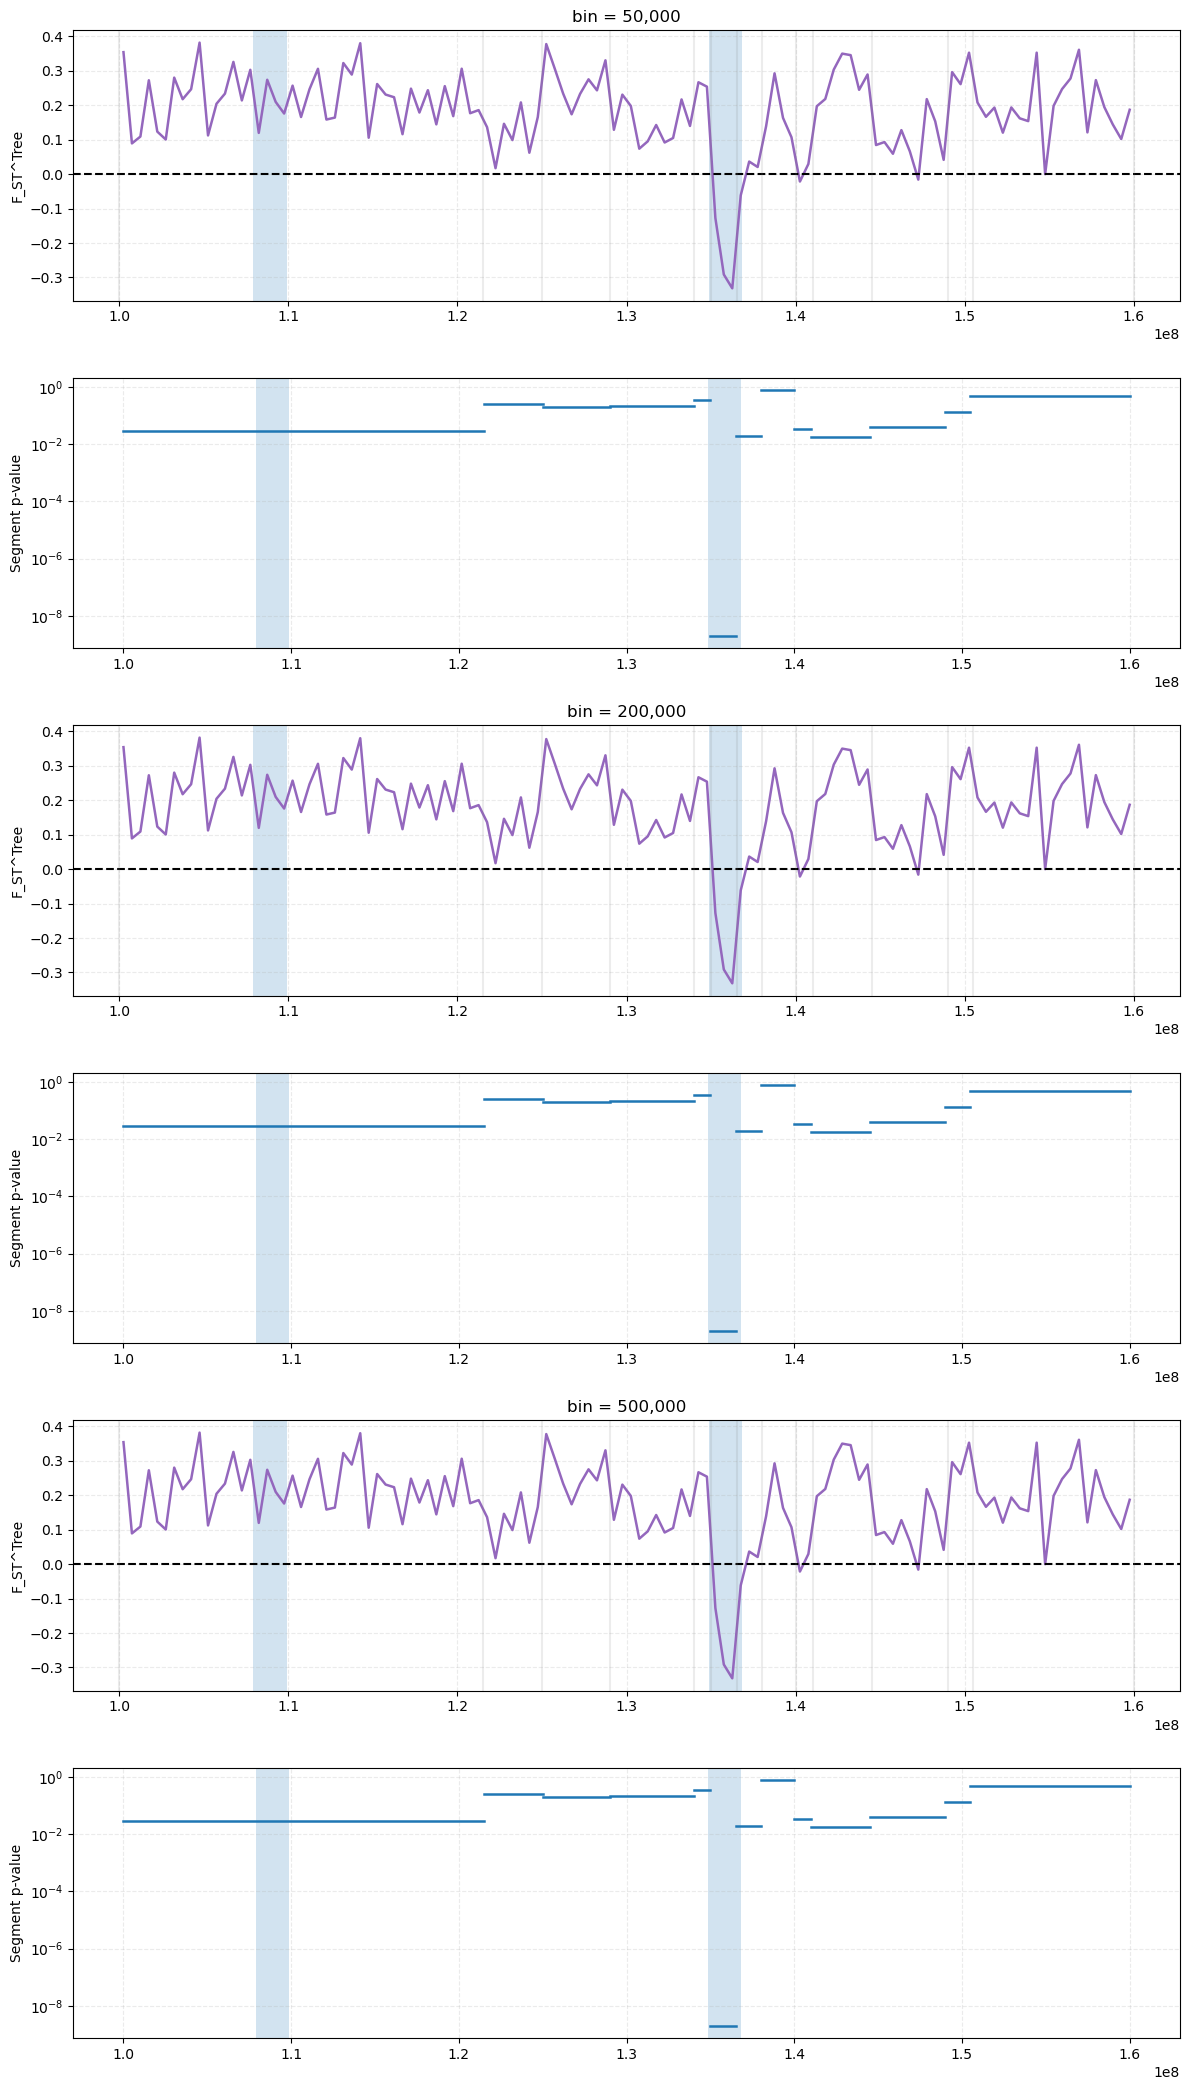

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import ruptures as rpt
from pathlib import Path

# -------------------------
# Settings
# -------------------------
CP_KERNEL = 'linear'
CP_AVG_SEGMENT_BP = 5_000_000
CP_MAX_LAG = 5
CP_WEIGHTS = 'gaussian'
CP_TWO_SIDED_PVALUE = True
CP_ROI = (100_000_000, 160_000_000)

bin_sizes_fst = [50_000, 200_000, 500_000]

# -------------------------
# Helper functions (unchanged)
# -------------------------
def _lag_cov(arr, lag):
    arr = np.asarray(arr, dtype=float)
    if lag <= 0:
        return np.cov(arr, arr)[0, 1]
    if lag >= len(arr):
        return 0.0
    return np.cov(arr[lag:], arr[:-lag])[0, 1]

def gaussian_weights(n):
    w = np.arange(1, n + 1)
    m = (n + 1) / 2.0
    w = norm.pdf(5 * (w - m) / (n + 1))
    return w / w.sum()

def segment_signal(signal, n_bkps, kernel='linear'):
    signal = np.asarray(signal, dtype=float)
    s = signal.std()
    s = s if s > 0 else 1.0
    algo = rpt.KernelCPD(kernel=kernel).fit(signal / s)
    bkps = algo.predict(n_bkps=n_bkps)
    bkps = np.r_[0, bkps]
    labels = np.repeat(np.arange(len(bkps) - 1), np.diff(bkps))
    return labels

# -------------------------
# Create stacked figure:
# 2 rows per bin size
# -------------------------
n_rows = 2 * len(bin_sizes_fst)
fig, axes = plt.subplots(n_rows, 1, figsize=(12, 3.5 * n_rows), sharex=False)

if n_rows == 1:
    axes = [axes]

for i, bin_size_fst in enumerate(bin_sizes_fst):

    # ----------------------------------------
    # Recompute coarse_mid, fst_bin, mask
    # (REUSE your previous FST binning block)
    # ----------------------------------------
    # You must call your FST binning code here.
    # It must produce:
    #   coarse_mid
    #   fst_bin
    #   mask

    # --- assume they are already computed for this bin_size_fst ---

    x = np.asarray(coarse_mid)[np.asarray(mask)]
    y = np.asarray(fst_bin)[np.asarray(mask)]

    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]

    if len(x) < 6:
        continue

    dx = float(np.median(np.diff(np.sort(x))))
    left = x - dx / 2.0
    right = x + dx / 2.0

    df_cp = pd.DataFrame({
        'mid': x,
        'left': left,
        'right': right,
        'fst_tree': y,
    }).sort_values('mid').reset_index(drop=True)

    if CP_ROI is not None:
        roi_left, roi_right = CP_ROI
        df_cp = df_cp[(df_cp['right'] > roi_left) & (df_cp['left'] < roi_right)].copy()
        df_cp['left'] = np.maximum(df_cp['left'], roi_left)
        df_cp['right'] = np.minimum(df_cp['right'], roi_right)
        df_cp = df_cp[df_cp['right'] > df_cp['left']].reset_index(drop=True)

    if len(df_cp) < 6:
        continue

    # ----------------------------------------
    # Changepoint segmentation
    # ----------------------------------------
    span = float(df_cp['right'].max() - df_cp['left'].min())
    n_bkps = max(1, int(round(span / CP_AVG_SEGMENT_BP)))
    n_bkps = min(n_bkps, max(1, len(df_cp) - 2))

    labels = segment_signal(df_cp['fst_tree'], n_bkps=n_bkps, kernel=CP_KERNEL)
    df_cp['segment'] = labels

    mu_g = float(df_cp['fst_tree'].mean())
    cov = np.array([_lag_cov(df_cp['fst_tree'], k) for k in range(CP_MAX_LAG)])

    # Compute segment means
    seg_df = (
        df_cp.groupby('segment', sort=False)
        .agg(
            left=('left', 'first'),
            right=('right', 'last'),
            mid=('mid', 'mean'),
            segment_mean=('fst_tree', 'mean'),
            n_points=('fst_tree', 'size'),
        )
        .reset_index()
    )

    # Very simplified p-value version (same as your logic)
    pvals = []
    for seg_id in seg_df['segment']:
        xseg = df_cp[df_cp['segment'] == seg_id]['fst_tree'].to_numpy()
        w = gaussian_weights(len(xseg))
        x_bar = (xseg * w).sum()
        var = (w**2).sum() * cov[0]
        sem = np.sqrt(var) if var > 0 else np.nan
        if not np.isfinite(sem):
            pvals.append(np.nan)
        else:
            z = (x_bar - mu_g) / sem
            pvals.append(2 * (1 - norm.cdf(abs(z))))

    seg_df['p_value'] = pvals

    # ----------------------------------------
    # Plot
    # ----------------------------------------
    ax_top = axes[2*i]
    ax_bot = axes[2*i + 1]

    # Highlight regions
    pos = 135_851_076
    half = 1_000_000
    pos2 = 108_897_145
    half2 = 1_000_000

    for ax in (ax_top, ax_bot):
        ax.axvspan(pos - half, pos + half, alpha=0.2)
        ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

    # Top panel
    ax_top.plot(df_cp['mid'], df_cp['fst_tree'],
                color='tab:purple', linewidth=1.8)
    ax_top.axhline(0.0, color='black', linestyle='--')
    ax_top.set_title(f'bin = {bin_size_fst:,}')
    ax_top.set_ylabel('F_ST^Tree')
    ax_top.grid(alpha=0.25, linestyle='--')

    bounds = np.unique(np.r_[seg_df['left'], seg_df['right']])
    for b in bounds:
        ax_top.axvline(b, color='gray', alpha=0.15)

    # Bottom panel
    for _, row in seg_df.iterrows():
        ax_bot.plot([row['left'], row['right']],
                    [row['p_value'], row['p_value']],
                    color='tab:blue', linewidth=1.8)

    ax_bot.set_yscale('log')
    ax_bot.set_ylabel('Segment p-value')
    ax_bot.grid(alpha=0.25, linestyle='--')

plt.tight_layout()
plt.show()

# Argweaver

## CEU vs JPT: Location vs mean D1F (post-burn-in, bin=100,000)

This section loads post-burn-in per-sample D1F CSVs from the new ARGweaver output layout, bins by 100,000 bp, and averages the binned curve over MCMC samples for each population (CEU, JPT).


CEU: 21 MCMC samples used
JPT: 21 MCMC samples used


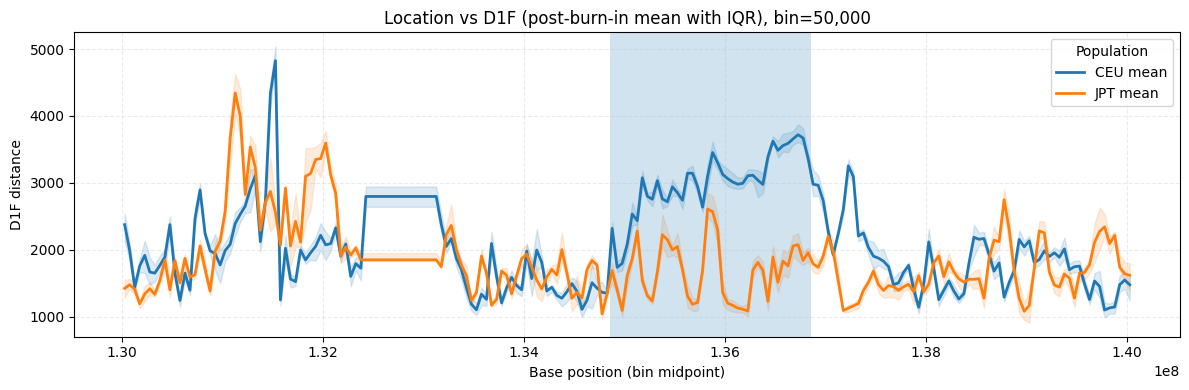

In [2]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

target_pops = ['CEU', 'JPT']
bin_size = 50_000

def load_pop_samples(pop: str):
    pattern = f'*_{pop}20/d1f_postburnin/*_d1f_per_tree_postburnin.csv'
    csv_paths = sorted(results_root.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f'No post-burn-in CSVs found for {pop} under {results_root}')

    sample_dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)

        dist_col = next((c for c in ['d1f_distance', 'distance', 'dif_distance'] if c in df.columns), None)
        if dist_col is None:
            raise KeyError(f'{p}: missing distance column')
        if not {'left', 'right'}.issubset(df.columns):
            raise KeyError(f'{p}: missing left/right columns')

        sample_match = re.search(r'sample(\d+)', p.name.lower())
        sample_id = int(sample_match.group(1)) if sample_match else None

        d = df[['left', 'right', dist_col]].copy()
        d.columns = ['left', 'right', 'd1f']
        d['sample'] = sample_id

        for c in ['left', 'right', 'd1f']:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        d = d.dropna(subset=['left', 'right', 'd1f'])
        d = d[d['right'] > d['left']]
        d = d.sort_values('left')

        if len(d):
            sample_dfs.append(d)

    if not sample_dfs:
        raise ValueError(f'All sample files for {pop} were empty after cleaning.')

    return sample_dfs

def binned_weighted_mean(df: pd.DataFrame, bin_left, bin_right):
    seg_left = df['left'].to_numpy(dtype=float)
    seg_right = df['right'].to_numpy(dtype=float)
    seg_val = df['d1f'].to_numpy(dtype=float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)
    return out

# Load sample-level D1F data
pop_samples = {pop: load_pop_samples(pop) for pop in target_pops}

# Shared bin edges across both populations
x0 = min(df['left'].min() for dfs in pop_samples.values() for df in dfs)
x1 = max(df['right'].max() for dfs in pop_samples.values() for df in dfs)
x0 = (int(x0) // bin_size) * bin_size
x1 = int(np.ceil(x1 / bin_size) * bin_size)

bin_edges = np.arange(x0, x1 + bin_size, bin_size, dtype=np.int64)
bin_left = bin_edges[:-1]
bin_right = bin_edges[1:]
bin_mid = (bin_left + bin_right) / 2.0

# Average (mean) curve over MCMC samples + quantile bands per population
pop_stats = {}
for pop, dfs in pop_samples.items():
    per_sample_curves = np.vstack([binned_weighted_mean(d, bin_left, bin_right) for d in dfs])

    pop_stats[pop] = {
        'mean': np.nanmean(per_sample_curves, axis=0),
        'median': np.nanmedian(per_sample_curves, axis=0),
        'q1': np.nanquantile(per_sample_curves, 0.25, axis=0),
        'q3': np.nanquantile(per_sample_curves, 0.75, axis=0),
    }
    print(f'{pop}: {len(dfs)} MCMC samples used')

# Plot 2 lines (means) + quantile bands (Q1-Q3), styled like neutral-overlay section
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'CEU': 'tab:blue', 'JPT': 'tab:orange'}

for pop in target_pops:
    stats = pop_stats[pop]
    color = colors.get(pop, None)

    qmask = np.isfinite(stats['q1']) & np.isfinite(stats['q3'])
    ax.fill_between(bin_mid[qmask], stats['q1'][qmask], stats['q3'][qmask], color=color, alpha=0.15)

    mmask = np.isfinite(stats['mean'])
    ax.plot(bin_mid[mmask], stats['mean'][mmask], color=color, linewidth=2.0, label=f'{pop} mean')

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance')
ax.set_title(f'Location vs D1F (post-burn-in mean with IQR), bin={bin_size:,}')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Population')
fig.tight_layout()
plt.show()


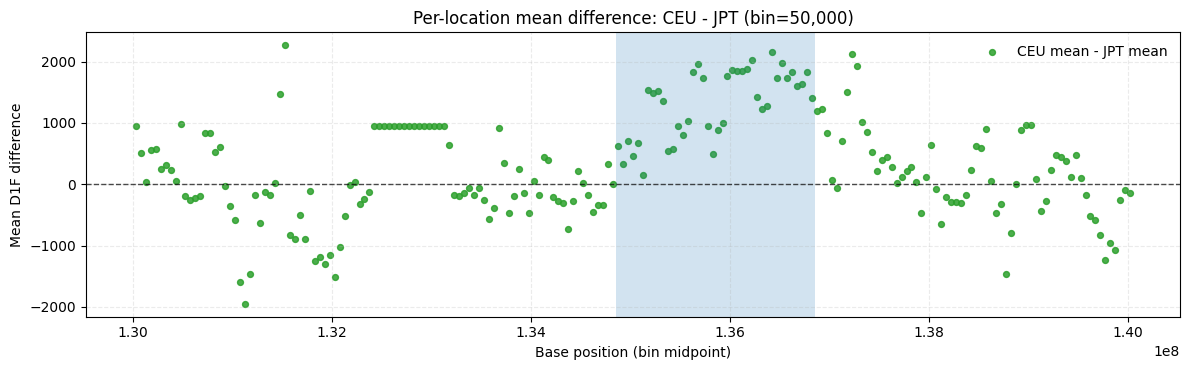

In [3]:
# CEU-JPT mean D1F difference per location (same bins as above)
diff_mean = pop_stats['CEU']['mean'] - pop_stats['JPT']['mean']
mask = np.isfinite(diff_mean)

fig, ax = plt.subplots(figsize=(12, 3.8))
ax.scatter(bin_mid[mask], diff_mean[mask], color='tab:green', s=18, alpha=0.85, label='CEU mean - JPT mean')
ax.axhline(0.0, color='black', linewidth=1.0, linestyle='--', alpha=0.7)

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('Mean D1F difference')
ax.set_title(f'Per-location mean difference: CEU - JPT (bin={bin_size:,})')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()



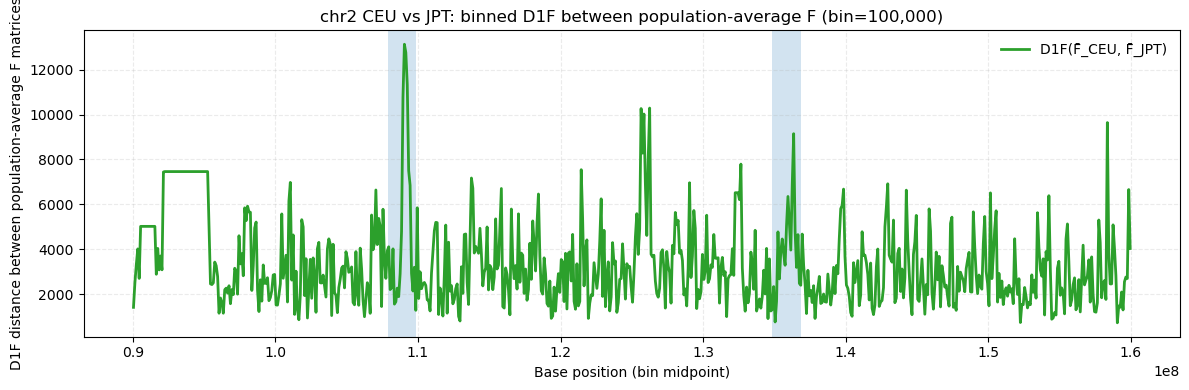

Loaded: results\chr2_50samples_CEU_JPT_d1f_between_pop_binned_bin100000.csv
Bins plotted: 700 / 700


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# --------------------------
# User-configurable settings
# --------------------------
chrom_pair = 2
pop_a = "CEU"
pop_b = "JPT"
bin_size_pair = 100_000
region_pair = None  # e.g. (90_000_000, 160_000_000)

results_dir = Path("results")
pair_csv = results_dir / f"chr{chrom_pair}_50samples_{pop_a}_{pop_b}_d1f_between_pop_binned_bin{bin_size_pair}.csv"

if not pair_csv.exists():
    raise FileNotFoundError(
        f"Missing binned CEU/JPT file: {pair_csv}. Run the new binned chunk in chr2_50samples_d1f.Rmd first."
    )

pair_df = pd.read_csv(pair_csv)
required = ["bin_left", "bin_right", "bin_mid", "d1f_distance_between_pops"]
missing = [c for c in required if c not in pair_df.columns]
if missing:
    raise KeyError(f"{pair_csv}: missing required columns {missing}")

for c in required:
    pair_df[c] = pd.to_numeric(pair_df[c], errors="coerce")

pair_df = pair_df.dropna(subset=required).sort_values("bin_left").reset_index(drop=True)

if region_pair is not None:
    L0, R0 = region_pair
    pair_df = pair_df[
        (pair_df["bin_right"] > L0) & (pair_df["bin_left"] < R0)
    ].copy()

mask = np.isfinite(pair_df["d1f_distance_between_pops"].to_numpy(float))

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    pair_df.loc[mask, "bin_mid"],
    pair_df.loc[mask, "d1f_distance_between_pops"],
    color="tab:green",
    linewidth=2.0,
    label=f"D1F(F̄_{pop_a}, F̄_{pop_b})"
)

pos = 135_851_076
half = 1_000_000
ax.axvspan(pos - half, pos + half, alpha=0.2)

pos2 = 108_897_145
half2 = 1_000_000
ax.axvspan(pos2 - half2, pos2 + half2, alpha=0.2)

ax.set_xlabel("Base position (bin midpoint)")
ax.set_ylabel("D1F distance between population-average F matrices")
ax.set_title(
    f"chr{chrom_pair} {pop_a} vs {pop_b}: "
    f"binned D1F between population-average F (bin={bin_size_pair:,})"
)

ax.grid(alpha=0.25, linestyle="--")
ax.legend(frameon=False)

fig.tight_layout()
plt.show()

print(f"Loaded: {pair_csv}")
print(f"Bins plotted: {int(mask.sum())} / {len(mask)}")

## Neutral SLiM Simulations For ARGweaver-Matched Populations (s=0)

This section runs **20 neutral SLiM simulations per population** (CEU, JPT) using the ARGweaver region settings and population-specific recombination maps.  
Each replicate then runs `recap.py` to recapitate, add neutral mutations, and downsample to 40 haploid genomes (20 diploids).



In [1]:
from pathlib import Path
import subprocess
import numpy as np
import pandas as pd

# Resolve repository root robustly
repo_root = Path.cwd()
if not (repo_root / 'Simulation').exists():
    for p in repo_root.parents:
        if (p / 'Simulation').exists():
            repo_root = p
            break

# Output root for neutral SLiM trees used as empirical baseline generation
neutral_root = repo_root / '1000Genomes' / 'raw_data' / 'data' / 'neutral_slim'
neutral_root.mkdir(parents=True, exist_ok=True)

# Pop-specific settings (match ARGweaver-scale settings; edit Ne if you used different values)
pop_configs = {
    'CEU': {
        'Ne': 14000,
        'mu': 1.25e-8,
    },
    'JPT': {
        'Ne': 14000,
        'mu': 1.25e-8,
    },
}

N_HAPLOID = 40                 # 20 diploid individuals
N_REPS = 20
FORWARD_GENERATIONS = 10000    # forward SLiM generations before recapitation
SEED_BASE = 9100000

slim_bin = 'slim'
recap_py = repo_root / 'Simulation' / 'Slim(primary)' / 'recap.py'
if not recap_py.exists():
    raise FileNotFoundError(f'Missing recap script: {recap_py}')



In [2]:
def load_recomb_map_for_slim(pop: str):
    """Read ARGweaver bedgraph recomb map and convert to SLiM vectors."""
    map_path = (
        repo_root
        / '1000Genomes' / 'raw_data' / 'data' / 'runs'
        / f'argweaver_chr2_130_140Mb_{pop}20'
        / 'intermediate'
        / 'recomb_map_chr2_130000000_140000000.bedgraph'
    )
    if not map_path.exists():
        raise FileNotFoundError(f'Missing recombination map for {pop}: {map_path}')

    df = pd.read_csv(map_path, sep='	', header=None, names=['chrom', 'start', 'end', 'rate'])
    if df.empty:
        raise ValueError(f'Empty recombination map for {pop}: {map_path}')

    region_start = int(df['start'].min())
    region_end = int(df['end'].max())
    seq_len = region_end - region_start

    # SLiM initializeRecombinationRate(rates, ends): len(ends) == len(rates)
    ends = (df['end'].astype(int) - region_start - 1).clip(lower=0).tolist()
    rates = df['rate'].astype(float).tolist()

    # Ensure final endpoint equals sequence length - 1
    if ends[-1] != seq_len - 1:
        ends[-1] = seq_len - 1

    return {
        'map_path': map_path,
        'region_start': region_start,
        'region_end': region_end,
        'seq_len': seq_len,
        'rates': rates,
        'ends': ends,
    }


def build_neutral_slim_script(seq_len: int, Ne: int, rates, ends, generations: int):
    rates_str = ', '.join(f'{r:.16g}' for r in rates)
    ends_str = ', '.join(str(e) for e in ends)

    template = """initialize() {{
    if (exists("slimgui")) {{
        defineConstant("simID", 1);
    }}
    initializeTreeSeq();
    initializeMutationRate(0);
    initializeMutationType("m1", 0.5, "f", 0.0);
    initializeGenomicElementType("g1", m1, 1.0);
    initializeGenomicElement(g1, 0, asInteger({seq_len} - 1));
    initializeRecombinationRate(c({rates_str}), c({ends_str}));
}}

1 early() {{
    sim.addSubpop("p1", asInteger({Ne}));
}}

{generations} late() {{
    sim.treeSeqOutput("trees/" + simID + \".trees");
    sim.simulationFinished();
}}
"""
    return template.format(
        seq_len=seq_len,
        rates_str=rates_str,
        ends_str=ends_str,
        Ne=Ne,
        generations=generations,
    )



In [3]:
def run_neutral_slim_for_population(pop: str, cfg: dict, n_reps: int = N_REPS):
    map_info = load_recomb_map_for_slim(pop)

    pop_dir = neutral_root / pop
    slimfiles_dir = pop_dir / 'slimfiles'
    trees_dir = pop_dir / 'trees'
    checkpoints_dir = pop_dir / 'checkpoints'
    for d in (slimfiles_dir, trees_dir, checkpoints_dir):
        d.mkdir(parents=True, exist_ok=True)

    slim_script = build_neutral_slim_script(
        seq_len=map_info['seq_len'],
        Ne=int(cfg['Ne']),
        rates=map_info['rates'],
        ends=map_info['ends'],
        generations=FORWARD_GENERATIONS,
    )

    slim_file = slimfiles_dir / f'neutral_{pop}_s0.slim'
    slim_file.write_text(slim_script)

    rows = []
    for rep in range(n_reps):
        sim_id = SEED_BASE + (100000 if pop == 'JPT' else 0) + rep

        raw_ts = trees_dir / f'{sim_id}.trees'
        recap_ts = trees_dir / f'r{sim_id}.trees'

        # Skip already-complete replicates
        if raw_ts.exists() and recap_ts.exists():
            rows.append({'population': pop, 'replicate': rep, 'sim_id': sim_id, 'raw_ts': str(raw_ts), 'recap_ts': str(recap_ts), 'status': 'existing'})
            continue

        slim_cmd = [
            slim_bin,
            '-s', str(sim_id),
            '-d', f'simID={sim_id}',
            str(slim_file),
        ]
        subprocess.run(slim_cmd, cwd=pop_dir, check=True)

        recap_cmd = [
            'python',
            str(recap_py),
            str(sim_id),
            str(N_HAPLOID),
            str(int(cfg['Ne'])),
            '0.0',                    # recap recombination already encoded in SLiM trees
            str(float(cfg['mu'])),
        ]
        subprocess.run(recap_cmd, cwd=pop_dir, check=True)

        rows.append({'population': pop, 'replicate': rep, 'sim_id': sim_id, 'raw_ts': str(raw_ts), 'recap_ts': str(recap_ts), 'status': 'generated'})

    manifest = pd.DataFrame(rows)
    manifest_path = pop_dir / f'neutral_manifest_{pop}.csv'
    manifest.to_csv(manifest_path, index=False)

    print(f'[{pop}] complete: {len(manifest)} replicates')
    print(f'[{pop}] manifest: {manifest_path}')
    print(f'[{pop}] recomb map: {map_info["map_path"]}')

    return manifest



In [ ]:
# Run 20 neutral SLiM replicates per population (CEU, JPT)
manifests = {}
for pop, cfg in pop_configs.items():
    manifests[pop] = run_neutral_slim_for_population(pop, cfg, n_reps=N_REPS)

summary = pd.concat(manifests.values(), ignore_index=True)
summary.groupby(['population', 'status']).size().rename('n').reset_index()



## Neutral TreeSequence Conversion Only (`.trees` -> `.tree` + `_breaks.csv`)
 
It converts neutral recapitated SLiM tree sequences directly into:
- cleaned Newick files (`*.tree`, one tree per line)
- breakpoint tables (`*_breaks.csv`)

Output layout matches the Rmd expectations:
- `raw_data/data/runs_neutral_slim_argweaver/argweaver_<RUN_TAG>/trees/*.tree`
- `raw_data/data/results/<RUN_TAG>/breakpoints/*_breaks.csv`



In [7]:
from pathlib import Path
import csv
import tskit

repo_root = Path.cwd()
if not (repo_root / 'Simulation').exists():
    for p in repo_root.parents:
        if (p / 'Simulation').exists():
            repo_root = p
            break

data_root = repo_root / '1000Genomes' / 'raw_data' / 'data'
neutral_root = data_root / 'neutral_slim'
neutral_runs_root = data_root / 'runs_neutral_slim_argweaver'
results_root = data_root / 'results'

neutral_runs_root.mkdir(parents=True, exist_ok=True)
results_root.mkdir(parents=True, exist_ok=True)

REGION_START = 130_000_000
REGION_END = 140_000_000


def discover_recap_trees(pop: str, max_n: int = 20):
    pop_dir = neutral_root / pop
    manifest_path = pop_dir / f'neutral_manifest_{pop}.csv'

    tpaths = []
    if manifest_path.exists():
        import pandas as pd
        m = pd.read_csv(manifest_path)
        if 'recap_ts' in m.columns:
            tpaths = [Path(x) for x in m['recap_ts'].tolist() if isinstance(x, str)]
            tpaths = [p for p in tpaths if p.exists()]

    if not tpaths:
        tpaths = sorted((pop_dir / 'trees').glob('r*.trees'))

    return sorted(tpaths)[:max_n]


def ts_to_newick_and_breaks(ts_path: Path, out_tree: Path, out_breaks_csv: Path, stem: str, region_start: int):
    ts = tskit.load(ts_path)

    sample_nodes = list(ts.samples())
    labels = {u: f'h{i}' for i, u in enumerate(sample_nodes)}

    out_tree.parent.mkdir(parents=True, exist_ok=True)
    out_breaks_csv.parent.mkdir(parents=True, exist_ok=True)

    with open(out_tree, 'w') as ftree, open(out_breaks_csv, 'w', newline='') as fcsv:
        w = csv.writer(fcsv)
        w.writerow(['file', 'tree_index', 'left', 'right', 'mid'])

        for tree in ts.trees():
            # Newick for current local tree
            nwk = tree.as_newick(root=tree.root, node_labels=labels)
            ftree.write(nwk + "\n")

            l = float(region_start + tree.interval.left)
            r = float(region_start + tree.interval.right)
            m = 0.5 * (l + r)
            w.writerow([stem, int(tree.index), l, r, m])


def convert_population(pop: str, max_n: int = 20):
    ts_files = discover_recap_trees(pop, max_n=max_n)
    if len(ts_files) == 0:
        print(f'[{pop}] no recap trees found')
        return []

    # Single neutral run directory per population (Rmd expects argweaver_* style naming)
    run_tag = f'chr2_130_140Mb_{pop}20_neutral'
    run_dir = neutral_runs_root / f'argweaver_{run_tag}'
    tree_dir = run_dir / 'trees'
    breaks_dir = results_root / run_tag / 'breakpoints'

    tree_dir.mkdir(parents=True, exist_ok=True)
    breaks_dir.mkdir(parents=True, exist_ok=True)

    rows = []
    for i, ts_path in enumerate(ts_files, start=0):
        # Set sample IDs > 90 so existing Rmd post-burn-in filter keeps them.
        sample_id = 100 + 10 * i
        stem = f'{pop.lower()}_sample{sample_id}'

        out_tree = tree_dir / f'{stem}.tree'
        out_breaks = breaks_dir / f'{stem}_breaks.csv'

        ts_to_newick_and_breaks(
            ts_path=ts_path,
            out_tree=out_tree,
            out_breaks_csv=out_breaks,
            stem=stem,
            region_start=REGION_START,
        )

        rows.append({
            'population': pop,
            'ts_path': str(ts_path),
            'run_tag': run_tag,
            'tree_file': str(out_tree),
            'breaks_file': str(out_breaks),
            'sample_id': sample_id,
        })

    return rows


all_rows = []
for pop in ['CEU', 'JPT']:
    all_rows.extend(convert_population(pop, max_n=20))

if all_rows:
    import pandas as pd
    manifest = pd.DataFrame(all_rows)
    manifest_path = neutral_runs_root / 'neutral_trees_direct_conversion_manifest.csv'
    manifest.to_csv(manifest_path, index=False)
    print(f'Wrote conversion manifest: {manifest_path}')
    display(manifest.groupby('population').size().rename('n_files').reset_index())
else:
    print('No files converted.')



Wrote conversion manifest: /Users/yagishinnosuke/Documents/2025-2026 Stanford/Palacios Lab/Selective-Sweep-Simulation/1000Genomes/raw_data/data/runs_neutral_slim_argweaver/neutral_trees_direct_conversion_manifest.csv


,population,n_files
0,CEU,20
1,JPT,20


## CEU vs JPT: Location vs mean D1F to empirical neutral mean (post-burn-in)

This section reproduces the distance-vs-location plot using the empirical-neutral-reference outputs from `chr2_20samples_d1f_argweaver.Rmd` (`*_postburnin_empirical_neutral.csv`).



CEU: 21 empirical-reference samples used
JPT: 21 empirical-reference samples used


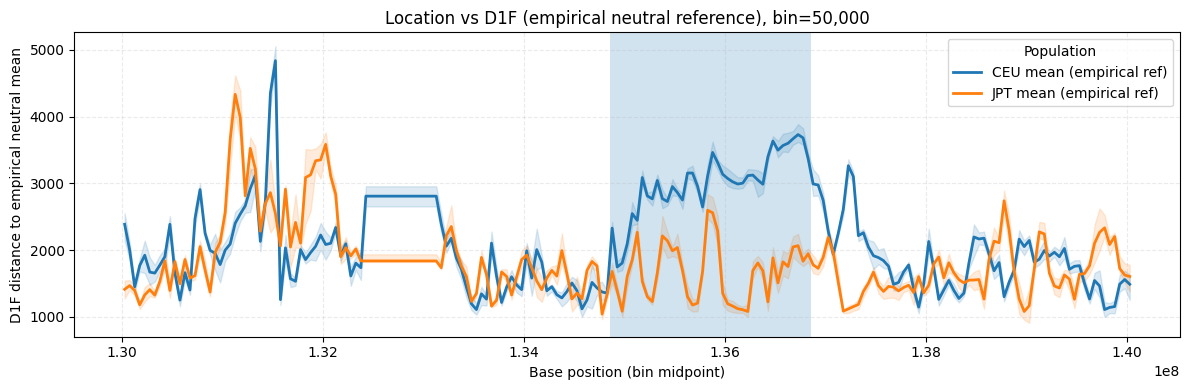

In [8]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

target_pops_emp = ['CEU', 'JPT']
bin_size_emp = 50_000


def load_pop_samples_empirical(pop: str):
    pattern = f'*_{pop}20/d1f_postburnin_empirical_neutral/*_d1f_per_tree_postburnin_empirical_neutral.csv'
    csv_paths = sorted(results_root.glob(pattern))
    if not csv_paths:
        raise FileNotFoundError(f'No empirical-neutral CSVs found for {pop} under {results_root}')

    sample_dfs = []
    for p in csv_paths:
        df = pd.read_csv(p)

        dist_col = next((c for c in ['d1f_distance', 'distance', 'dif_distance'] if c in df.columns), None)
        if dist_col is None:
            raise KeyError(f'{p}: missing distance column')
        if not {'left', 'right'}.issubset(df.columns):
            raise KeyError(f'{p}: missing left/right columns')

        sample_match = re.search(r'sample(\d+)', p.name.lower())
        sample_id = int(sample_match.group(1)) if sample_match else None

        d = df[['left', 'right', dist_col]].copy()
        d.columns = ['left', 'right', 'd1f_emp']
        d['sample'] = sample_id

        for c in ['left', 'right', 'd1f_emp']:
            d[c] = pd.to_numeric(d[c], errors='coerce')
        d = d.dropna(subset=['left', 'right', 'd1f_emp'])
        d = d[d['right'] > d['left']]
        d = d.sort_values('left')

        if len(d):
            sample_dfs.append(d)

    if not sample_dfs:
        raise ValueError(f'All empirical-neutral files for {pop} were empty after cleaning.')

    return sample_dfs


def binned_weighted_mean_emp(df: pd.DataFrame, bin_left, bin_right):
    seg_left = df['left'].to_numpy(dtype=float)
    seg_right = df['right'].to_numpy(dtype=float)
    seg_val = df['d1f_emp'].to_numpy(dtype=float)

    out = np.full(len(bin_left), np.nan, dtype=float)
    for i, (L, R) in enumerate(zip(bin_left, bin_right)):
        overlap = np.minimum(seg_right, R) - np.maximum(seg_left, L)
        m = overlap > 0
        if np.any(m):
            w = overlap[m]
            out[i] = np.sum(w * seg_val[m]) / np.sum(w)
    return out


# Load sample-level empirical-reference D1F data
pop_samples_emp = {pop: load_pop_samples_empirical(pop) for pop in target_pops_emp}

# Shared bin edges
x0 = min(df['left'].min() for dfs in pop_samples_emp.values() for df in dfs)
x1 = max(df['right'].max() for dfs in pop_samples_emp.values() for df in dfs)
x0 = (int(x0) // bin_size_emp) * bin_size_emp
x1 = int(np.ceil(x1 / bin_size_emp) * bin_size_emp)

bin_edges_emp = np.arange(x0, x1 + bin_size_emp, bin_size_emp, dtype=np.int64)
bin_left_emp = bin_edges_emp[:-1]
bin_right_emp = bin_edges_emp[1:]
bin_mid_emp = (bin_left_emp + bin_right_emp) / 2.0

# Aggregate over samples
pop_stats_emp = {}
for pop, dfs in pop_samples_emp.items():
    per_sample_curves = np.vstack([binned_weighted_mean_emp(d, bin_left_emp, bin_right_emp) for d in dfs])

    pop_stats_emp[pop] = {
        'mean': np.nanmean(per_sample_curves, axis=0),
        'median': np.nanmedian(per_sample_curves, axis=0),
        'q1': np.nanquantile(per_sample_curves, 0.25, axis=0),
        'q3': np.nanquantile(per_sample_curves, 0.75, axis=0),
    }
    print(f'{pop}: {len(dfs)} empirical-reference samples used')

# Plot
fig, ax = plt.subplots(figsize=(12, 4))
colors = {'CEU': 'tab:blue', 'JPT': 'tab:orange'}

for pop in target_pops_emp:
    stats = pop_stats_emp[pop]
    color = colors.get(pop, None)

    qmask = np.isfinite(stats['q1']) & np.isfinite(stats['q3'])
    ax.fill_between(bin_mid_emp[qmask], stats['q1'][qmask], stats['q3'][qmask], color=color, alpha=0.15)

    mmask = np.isfinite(stats['mean'])
    ax.plot(bin_mid_emp[mmask], stats['mean'][mmask], color=color, linewidth=2.0, label=f'{pop} mean (empirical ref)')

pos = 135_851_076
half = 1_000_000
L = pos - half
R = pos + half
ax.axvspan(L, R, alpha=0.2)

ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('D1F distance to empirical neutral mean')
ax.set_title(f'Location vs D1F (empirical neutral reference), bin={bin_size_emp:,}')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(title='Population')
fig.tight_layout()
plt.show()



## Verification: Theoretical vs Empirical Reference D1F

This diagnostic section confirms whether the empirical-reference pipeline is being used by directly comparing post-burn-in per-tree D1F outputs from:
- theoretical Kingman reference (`d1f_postburnin`)
- empirical neutral reference (`d1f_postburnin_empirical_neutral`)



,population,sample,n_rows,mean_theo,mean_emp,mean_diff_emp_minus_theo,abs_diff_mean,corr
0,CEU,100,13121,1857.923148,1867.356187,9.433039,9.564467,0.999990
1,CEU,110,13106,1850.773690,1860.276380,9.502690,9.632653,0.999990
2,CEU,120,12952,1867.434199,1876.942172,9.507973,9.629121,0.999990
3,CEU,130,12938,1868.242651,1877.807383,9.564732,9.651458,0.999991
4,CEU,140,13079,1861.906519,1871.682441,9.775922,9.849512,0.999992


,population,sample,n_rows,mean_theo,mean_emp,mean_diff_emp_minus_theo,abs_diff_mean,corr
0,JPT,100,15196,1737.297332,1727.604010,-9.693322,9.791298,0.999985
1,JPT,110,15130,1748.354832,1738.746969,-9.607863,9.727336,0.999985
2,JPT,120,14932,1734.573917,1724.981722,-9.592195,9.733924,0.999983
3,JPT,130,14983,1749.346406,1739.758061,-9.588344,9.724005,0.999984
4,JPT,140,14949,1728.169423,1718.654898,-9.514525,9.658993,0.999982


CEU mean abs diff: 9.842580550468131
JPT mean abs diff: 9.585830562612378
CEU mean corr: 0.9999907656483726
JPT mean corr: 0.9999831226582064


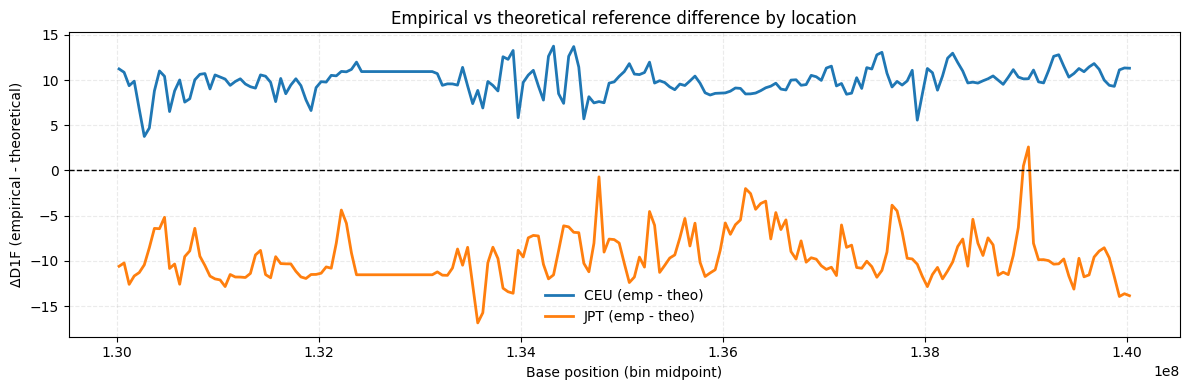

In [9]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = Path('.')
results_root = base / 'raw_data' / 'data' / 'results'

def sample_id_from_name(name: str):
    m = re.search(r'sample(\d+)', name.lower())
    return int(m.group(1)) if m else None

def compare_pop(pop: str):
    theo_dir = results_root / f'chr2_130_140Mb_{pop}20' / 'd1f_postburnin'
    emp_dir = results_root / f'chr2_130_140Mb_{pop}20' / 'd1f_postburnin_empirical_neutral'

    theo_files = sorted(theo_dir.glob(f'{pop.lower()}_sample*_d1f_per_tree_postburnin.csv'))
    emp_files = sorted(emp_dir.glob(f'{pop.lower()}_sample*_d1f_per_tree_postburnin_empirical_neutral.csv'))

    theo_map = {sample_id_from_name(p.name): p for p in theo_files}
    emp_map = {sample_id_from_name(p.name): p for p in emp_files}
    common = sorted(set(theo_map) & set(emp_map))

    if not common:
        raise ValueError(f'No matching sample IDs between theoretical and empirical for {pop}')

    rows = []
    merged_list = []
    for sid in common:
        t = pd.read_csv(theo_map[sid])
        e = pd.read_csv(emp_map[sid])

        # Align on genomic window identity
        key_cols = ['file', 'tree_index', 'left', 'right', 'mid']
        use_cols = [c for c in key_cols if c in t.columns and c in e.columns]
        m = t.merge(e, on=use_cols, suffixes=('_theo', '_emp'))

        if 'd1f_distance_theo' not in m.columns or 'd1f_distance_emp' not in m.columns:
            raise KeyError(f'{pop} sample {sid}: missing d1f_distance columns after merge')

        d = m['d1f_distance_emp'] - m['d1f_distance_theo']
        rows.append({
            'population': pop,
            'sample': sid,
            'n_rows': len(m),
            'mean_theo': float(m['d1f_distance_theo'].mean()),
            'mean_emp': float(m['d1f_distance_emp'].mean()),
            'mean_diff_emp_minus_theo': float(d.mean()),
            'abs_diff_mean': float(d.abs().mean()),
            'corr': float(m['d1f_distance_theo'].corr(m['d1f_distance_emp'])),
        })

        merged_list.append(m)

    summary = pd.DataFrame(rows).sort_values('sample')
    merged_all = pd.concat(merged_list, ignore_index=True)
    return summary, merged_all

summary_ceu, merged_ceu = compare_pop('CEU')
summary_jpt, merged_jpt = compare_pop('JPT')

display(summary_ceu.head())
display(summary_jpt.head())

print('CEU mean abs diff:', summary_ceu['abs_diff_mean'].mean())
print('JPT mean abs diff:', summary_jpt['abs_diff_mean'].mean())
print('CEU mean corr:', summary_ceu['corr'].mean())
print('JPT mean corr:', summary_jpt['corr'].mean())

# Difference-vs-location plot (empirical - theoretical), binned
bin_size = 50_000

def binned_delta(df):
    x0 = (int(df['left'].min()) // bin_size) * bin_size
    x1 = int(np.ceil(df['right'].max() / bin_size) * bin_size)
    edges = np.arange(x0, x1 + bin_size, bin_size)
    L = edges[:-1]
    R = edges[1:]
    M = (L + R) / 2.0
    out = np.full(len(L), np.nan)

    seg_l = df['left'].to_numpy(float)
    seg_r = df['right'].to_numpy(float)
    seg_d = (df['d1f_distance_emp'] - df['d1f_distance_theo']).to_numpy(float)

    for i, (a, b) in enumerate(zip(L, R)):
        ov = np.minimum(seg_r, b) - np.maximum(seg_l, a)
        mask = ov > 0
        if np.any(mask):
            w = ov[mask]
            out[i] = np.sum(w * seg_d[mask]) / np.sum(w)
    return M, out

mid_ceu, d_ceu = binned_delta(merged_ceu)
mid_jpt, d_jpt = binned_delta(merged_jpt)

fig, ax = plt.subplots(figsize=(12, 4))
mask = np.isfinite(d_ceu)
ax.plot(mid_ceu[mask], d_ceu[mask], color='tab:blue', linewidth=2, label='CEU (emp - theo)')
mask = np.isfinite(d_jpt)
ax.plot(mid_jpt[mask], d_jpt[mask], color='tab:orange', linewidth=2, label='JPT (emp - theo)')
ax.axhline(0.0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Base position (bin midpoint)')
ax.set_ylabel('ΔD1F (empirical - theoretical)')
ax.set_title('Empirical vs theoretical reference difference by location')
ax.grid(alpha=0.25, linestyle='--')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

